In [1]:
# LOAN DEFAULT PREDICTION MACHINE LEARNING MODEL

In [2]:
# Import Libaries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
# Loading the Data

In [5]:
df_loan = pd.read_csv('/Users/evansamoah/Desktop/Projects/Python/Loan Default Prediction/vehicle_loans.csv' , index_col='UNIQUEID')

In [6]:
df_loan.head()

,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,DISBURSAL_DATE,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
UNIQUEID,,,,,,,,,,,,,,,,,,,,,
420825,50578,58400,89.55,67,22807,45,1441,01-01-1984,Salaried,03-08-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
537409,47145,65550,73.23,67,22807,45,1502,31-07-1985,Self employed,26-09-2018,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
417566,53278,61360,89.63,67,22807,45,1497,24-08-1985,Self employed,01-08-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
624493,57513,66113,88.48,67,22807,45,1501,30-12-1993,Self employed,26-10-2018,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
539055,52378,60300,88.39,67,22807,45,1495,09-12-1977,Self employed,26-09-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1


In [7]:
#investigate shape
df_loan.shape

(233154, 40)

In [8]:
#print rows and columns
print("Number of rows: " , df_loan.shape[0])
print("Number of columns: " , df_loan.shape[1])

Number of rows:  233154
Number of columns:  40


In [9]:
# Investigate column types
df_loan.info()

<class 'pandas.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 40 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   DISBURSED_AMOUNT                     233154 non-null  int64  
 1   ASSET_COST                           233154 non-null  int64  
 2   LTV                                  233154 non-null  float64
 3   BRANCH_ID                            233154 non-null  int64  
 4   SUPPLIER_ID                          233154 non-null  int64  
 5   MANUFACTURER_ID                      233154 non-null  int64  
 6   CURRENT_PINCODE_ID                   233154 non-null  int64  
 7   DATE_OF_BIRTH                        233154 non-null  str    
 8   EMPLOYMENT_TYPE                      225493 non-null  str    
 9   DISBURSAL_DATE                       233154 non-null  str    
 10  STATE_ID                             233154 non-null  int64  
 11  EMPLOYEE_CODE_ID        

In [10]:
# convert disbursal date
df_loan['DISBURSAL_DATE'] = pd.to_datetime(df_loan['DISBURSAL_DATE'], format='%d-%m-%Y')

In [11]:
## minimum and maximum date
print("Maximum Disbursal Date: " , df_loan['DISBURSAL_DATE'].max())
print("Minimum Disbursal Date: " , df_loan['DISBURSAL_DATE'].min())

Maximum Disbursal Date:  2018-10-31 00:00:00
Minimum Disbursal Date:  2018-08-01 00:00:00


In [12]:
# timespan of data set
print("Timespan of Data Set: " , df_loan['DISBURSAL_DATE'].max() - df_loan['DISBURSAL_DATE'].min())

Timespan of Data Set:  91 days 00:00:00


In [13]:
# View Loan_Default
df_loan['LOAN_DEFAULT'].value_counts()

LOAN_DEFAULT
0    182543
1     50611
Name: count, dtype: int64

In [14]:
# View Loan_Default normalized
df_loan['LOAN_DEFAULT'].value_counts(normalize=True)

LOAN_DEFAULT
0    0.782929
1    0.217071
Name: proportion, dtype: float64

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/3840442939.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="LOAN_DEFAULT", data=df_loan, palette="Set2")


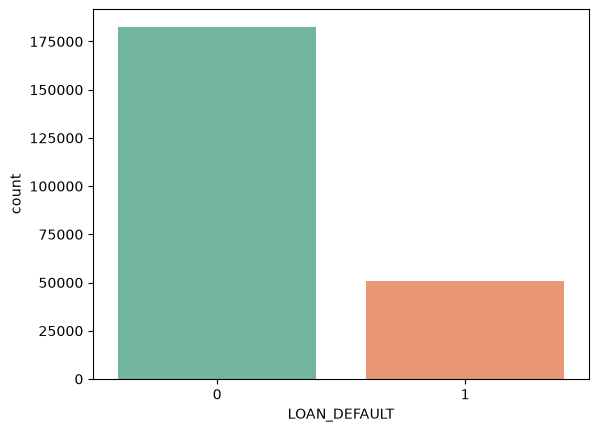

In [15]:
# plot Loan_Default
sns.countplot(x="LOAN_DEFAULT", data=df_loan, palette="Set2")
plt.show()

In [16]:
## Missing Data
df_loan.isnull().sum()

DISBURSED_AMOUNT                          0
ASSET_COST                                0
LTV                                       0
BRANCH_ID                                 0
SUPPLIER_ID                               0
MANUFACTURER_ID                           0
CURRENT_PINCODE_ID                        0
DATE_OF_BIRTH                             0
EMPLOYMENT_TYPE                        7661
DISBURSAL_DATE                            0
STATE_ID                                  0
EMPLOYEE_CODE_ID                          0
MOBILENO_AVL_FLAG                         0
AADHAR_FLAG                               0
PAN_FLAG                                  0
VOTERID_FLAG                              0
DRIVING_FLAG                              0
PASSPORT_FLAG                             0
PERFORM_CNS_SCORE                         0
PERFORM_CNS_SCORE_DESCRIPTION             0
PRI_NO_OF_ACCTS                           0
PRI_ACTIVE_ACCTS                          0
PRI_OVERDUE_ACCTS               

In [17]:
## Handling missing value
df_loan['EMPLOYMENT_TYPE'].value_counts()

EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Name: count, dtype: int64

In [18]:
df_loan['EMPLOYMENT_TYPE'].value_counts(normalize=True)

EMPLOYMENT_TYPE
Self employed    0.566026
Salaried         0.433974
Name: proportion, dtype: float64

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1636564150.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="EMPLOYMENT_TYPE", data=df_loan, palette="pastel")


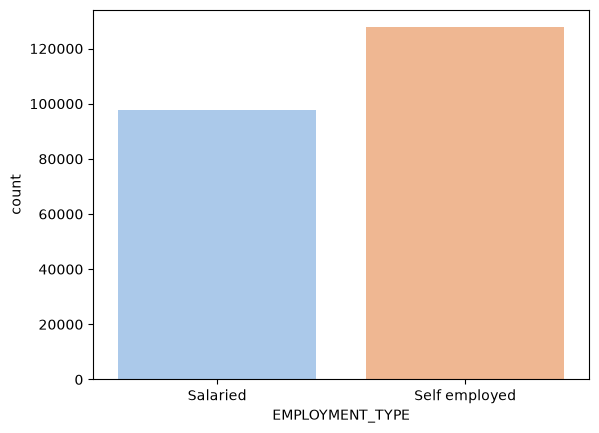

In [19]:
## plot Employment_Type
sns.countplot(x="EMPLOYMENT_TYPE", data=df_loan, palette="pastel")
plt.show()

In [20]:
## Missing Values Category
df_loan = df_loan.fillna(value={'EMPLOYMENT_TYPE' : 'Missing'})

EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Missing            7661
Name: count, dtype: int64


/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/3872308421.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="EMPLOYMENT_TYPE", data=df_loan, palette="rocket")


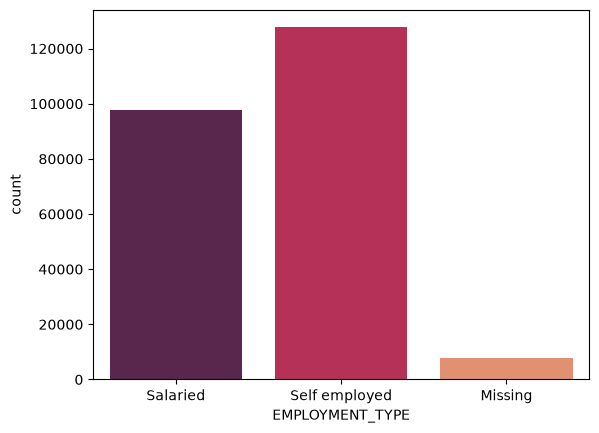

In [21]:
## plot employment type
print(df_loan['EMPLOYMENT_TYPE'].value_counts())
sns.countplot(x="EMPLOYMENT_TYPE", data=df_loan, palette="rocket")
plt.show()

In [22]:
#print DISBURSAL_DATE and DATE_OF-BIRTH
df_loan[['DISBURSAL_DATE', 'DATE_OF_BIRTH']].sample(10)

,DISBURSAL_DATE,DATE_OF_BIRTH
UNIQUEID,,
621789,2018-10-25,26-02-1997
457735,2018-08-23,15-08-1992
448278,2018-08-18,15-10-1980
489383,2018-09-04,11-12-1975
611602,2018-10-24,20-03-1992
429097,2018-08-09,05-09-1983
546062,2018-09-28,24-09-1986
617202,2018-10-25,27-04-1997
649509,2018-10-31,14-12-1982


In [23]:
#Calculating Age

In [24]:
# Convert dates
df_loan['DATE_OF_BIRTH'] = pd.to_datetime(df_loan['DATE_OF_BIRTH'], dayfirst=True, errors='coerce')
df_loan['DISBURSAL_DATE'] = pd.to_datetime(df_loan['DISBURSAL_DATE'], dayfirst=True, errors='coerce')

# Calculate age at disbursal
df_loan['AGE'] = (df_loan['DISBURSAL_DATE'] - df_loan['DATE_OF_BIRTH']).dt.days // 365

# Inspect the results
print(df_loan[['DATE_OF_BIRTH', 'AGE', 'DISBURSAL_DATE']].sample(n=5))

         DATE_OF_BIRTH  AGE DISBURSAL_DATE
UNIQUEID                                  
436312      1992-08-20   25     2018-08-13
476217      1984-05-01   34     2018-08-30
642253      1976-01-01   42     2018-10-30
527373      1978-01-01   40     2018-09-21
491777      1974-01-01   44     2018-09-06


In [25]:
df_loan['DISBURSAL_MONTH'] = df_loan['DISBURSAL_DATE'].dt.month
df_loan['DISBURSAL_MONTH'].value_counts()

DISBURSAL_MONTH
10    98364
8     68002
9     66788
Name: count, dtype: int64

In [26]:
df_loan = df_loan.drop(['DISBURSAL_DATE', 'DATE_OF_BIRTH'], axis=1)

In [27]:
# Strings sample 'CREDIT_HISTORY_LENGTH' & 'AVERAGE_ACCT_AGE
df_loan[['CREDIT_HISTORY_LENGTH', 'AVERAGE_ACCT_AGE']].sample(n=10)

,CREDIT_HISTORY_LENGTH,AVERAGE_ACCT_AGE
UNIQUEID,,
473280,3yrs 6mon,1yrs 1mon
498997,1yrs 0mon,0yrs 10mon
478338,0yrs 0mon,0yrs 0mon
647722,1yrs 1mon,0yrs 5mon
420766,0yrs 0mon,0yrs 0mon
642153,0yrs 6mon,0yrs 6mon
443187,2yrs 0mon,0yrs 11mon
484494,0yrs 0mon,0yrs 0mon
603136,2yrs 1mon,1yrs 0mon


In [28]:
#function that can calculate the total number of months based on a list of input strings
def calc_months(str_list):
    years = int(str_list[0])
    months = int(str_list[1])

    num_months = (years * 12) + months
    return num_months

In [29]:
#Extract relevant numbers from the original string data
df_loan['AVERAGE_ACCT_AGE_MONTHS'] = df_loan['AVERAGE_ACCT_AGE'].str.findall('\d+')
print(df_loan['AVERAGE_ACCT_AGE_MONTHS'].sample(n=10))

UNIQUEID
542313    [2, 10]
565960     [0, 0]
428917    [0, 10]
553218     [0, 0]
568420     [0, 3]
445127     [0, 0]
529333     [0, 6]
556255     [0, 0]
629466     [0, 6]
422021    [0, 10]
Name: AVERAGE_ACCT_AGE_MONTHS, dtype: object


In [30]:
#use map to perform calc_months across all rows
df_loan['AVERAGE_ACCT_AGE_MONTHS'] = df_loan['AVERAGE_ACCT_AGE_MONTHS'].map(calc_months)

In [31]:
#inspect results
print(df_loan[['AVERAGE_ACCT_AGE_MONTHS', 'AVERAGE_ACCT_AGE']].sample(n=10))

          AVERAGE_ACCT_AGE_MONTHS AVERAGE_ACCT_AGE
UNIQUEID                                          
534236                         19        1yrs 7mon
496222                          0        0yrs 0mon
490096                          0        0yrs 0mon
593466                          0        0yrs 0mon
519813                          0        0yrs 0mon
499191                          0        0yrs 0mon
611014                         23       1yrs 11mon
502280                          0        0yrs 0mon
556965                          0        0yrs 0mon
522068                          5        0yrs 5mon


In [32]:
#CREDIT_HISTORY_LENGTH
def convert_str_to_months(col_name):
    new_col = col_name + '_MONTHS'
    df_loan[new_col] = df_loan[col_name].str.findall('\d+')
    df_loan[new_col] = df_loan[new_col].map(calc_months)

In [33]:
#check results
convert_str_to_months('CREDIT_HISTORY_LENGTH')
df_loan[['CREDIT_HISTORY_LENGTH_MONTHS', 'CREDIT_HISTORY_LENGTH']].sample(n=5)

,CREDIT_HISTORY_LENGTH_MONTHS,CREDIT_HISTORY_LENGTH
UNIQUEID,,
613570,3,0yrs 3mon
443032,19,1yrs 7mon
647963,0,0yrs 0mon
538532,3,0yrs 3mon
505168,38,3yrs 2mon


In [34]:
#drop 'CREDIT_HISTORY_LENGTH' & 'AVERAGE_ACCT_AGE'y
df_loan = df_loan.drop(['AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH'], axis=1)

In [35]:
#use value_counts to investigate PERFORM_CNS_SCORE_DESCRIPTION
df_loan['PERFORM_CNS_SCORE_DESCRIPTION'].value_counts()

PERFORM_CNS_SCORE_DESCRIPTION
No Bureau History Available                                116950
C-Very Low Risk                                             16045
A-Very Low Risk                                             14124
D-Very Low Risk                                             11358
B-Very Low Risk                                              9201
M-Very High Risk                                             8776
F-Low Risk                                                   8485
K-High Risk                                                  8277
H-Medium Risk                                                6855
E-Low Risk                                                   5821
I-Medium Risk                                                5557
G-Low Risk                                                   3988
Not Scored: Sufficient History Not Available                 3765
J-High Risk                                                  3748
Not Scored: Not Enough Info available on the c

In [36]:
#save cleaned data
df_loan.to_csv('/Users/evansamoah/Desktop/Projects/Python/Loan Default Prediction/vehicle_loans_clean.csv')

In [37]:
# Exploratory Data Analysis

In [38]:
df2_loan = pd.read_csv('/Users/evansamoah/Desktop/Projects/Python/Loan Default Prediction/vehicle_loans_clean.csv' , index_col='UNIQUEID')

In [39]:
df2_loan.info()

<class 'pandas.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 40 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   DISBURSED_AMOUNT                     233154 non-null  int64  
 1   ASSET_COST                           233154 non-null  int64  
 2   LTV                                  233154 non-null  float64
 3   BRANCH_ID                            233154 non-null  int64  
 4   SUPPLIER_ID                          233154 non-null  int64  
 5   MANUFACTURER_ID                      233154 non-null  int64  
 6   CURRENT_PINCODE_ID                   233154 non-null  int64  
 7   EMPLOYMENT_TYPE                      233154 non-null  str    
 8   STATE_ID                             233154 non-null  int64  
 9   EMPLOYEE_CODE_ID                     233154 non-null  int64  
 10  MOBILENO_AVL_FLAG                    233154 non-null  int64  
 11  AADHAR_FLAG             

In [40]:
#investigate unique values
df2_loan.nunique()

DISBURSED_AMOUNT                       24565
ASSET_COST                             46252
LTV                                     6579
BRANCH_ID                                 82
SUPPLIER_ID                             2953
MANUFACTURER_ID                           11
CURRENT_PINCODE_ID                      6698
EMPLOYMENT_TYPE                            3
STATE_ID                                  22
EMPLOYEE_CODE_ID                        3270
MOBILENO_AVL_FLAG                          1
AADHAR_FLAG                                2
PAN_FLAG                                   2
VOTERID_FLAG                               2
DRIVING_FLAG                               2
PASSPORT_FLAG                              2
PERFORM_CNS_SCORE                        573
PERFORM_CNS_SCORE_DESCRIPTION             20
PRI_NO_OF_ACCTS                          108
PRI_ACTIVE_ACCTS                          40
PRI_OVERDUE_ACCTS                         22
PRI_CURRENT_BALANCE                    71341
PRI_SANCTI

In [41]:
df2_loan['MOBILENO_AVL_FLAG'].value_counts()

MOBILENO_AVL_FLAG
1    233154
Name: count, dtype: int64

In [42]:
#Drop MOBILENO_AVL_FLAG BECAUSE EVERY ROW CONTAINS THE VALUE 1 HENCE NO PREDICTIVE VALUE
df2_loan = df2_loan.drop(['MOBILENO_AVL_FLAG'], axis = 1)

In [43]:
# sample the iD columns
df2_loan[['SUPPLIER_ID', 'CURRENT_PINCODE_ID', 'EMPLOYEE_CODE_ID', 'BRANCH_ID', 'STATE_ID', 'MANUFACTURER_ID']].sample(10)

,SUPPLIER_ID,CURRENT_PINCODE_ID,EMPLOYEE_CODE_ID,BRANCH_ID,STATE_ID,MANUFACTURER_ID
UNIQUEID,,,,,,
493828,21043,3667,2796,121,9,86
604384,15680,1794,2179,135,4,45
515218,18317,2943,1565,16,17,86
536639,18006,1002,39,34,6,86
455733,20975,3469,2136,64,9,120
538203,23024,981,2246,34,6,86
620868,21081,1192,1642,34,6,45
571205,20379,7057,3454,104,10,86
450336,16633,2578,1720,74,4,45


In [44]:
#ID fields with large numbers of unique values will introduce complexity to predictive model

In [45]:
#Drop SUPPLIER_ID, CURRENT_PINCODE_ID, EMPLOYEE_CODE_ID, BRANCH_ID
df2_loan = df2_loan.drop(['SUPPLIER_ID', 'CURRENT_PINCODE_ID', 'EMPLOYEE_CODE_ID', 'BRANCH_ID'], axis=1)

In [46]:
#investigate MANUFACTURER_ID and STATE_ID

MANUFACTURER_ID
86     109534
45      56626
51      27204
48      16710
49      10220
120      9658
67       2405
145       778
153        12
152         6
156         1
Name: count, dtype: int64
MANUFACTURER_ID
86     0.469792
45     0.242870
51     0.116678
48     0.071669
49     0.043834
120    0.041423
67     0.010315
145    0.003337
153    0.000051
152    0.000026
156    0.000004
Name: proportion, dtype: float64


/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/2236469428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="MANUFACTURER_ID", data=df2_loan, palette="rocket")


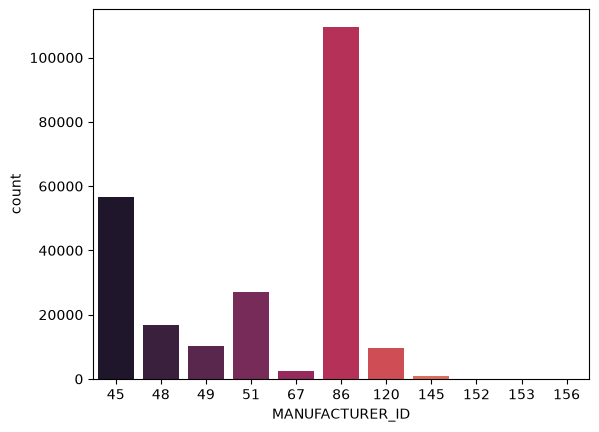

In [47]:
print(df2_loan['MANUFACTURER_ID'].value_counts())
print(df2_loan['MANUFACTURER_ID'].value_counts(normalize=True))
sns.countplot(x="MANUFACTURER_ID", data=df2_loan, palette="rocket")
plt.show()

In [48]:
#group by MANUFACTURER_ID
df2_loan.groupby('MANUFACTURER_ID')

In [49]:
#max groupby MANUFACTURER_ID
df2_loan.groupby('MANUFACTURER_ID').max()

,DISBURSED_AMOUNT,ASSET_COST,LTV,EMPLOYMENT_TYPE,STATE_ID,AADHAR_FLAG,PAN_FLAG,VOTERID_FLAG,DRIVING_FLAG,PASSPORT_FLAG,...,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,NO_OF_INQUIRIES,LOAN_DEFAULT,AGE,DISBURSAL_MONTH,AVERAGE_ACCT_AGE_MONTHS,CREDIT_HISTORY_LENGTH_MONTHS
MANUFACTURER_ID,,,,,,,,,,,,,,,,,,,,,
45,105768,123865,95.00,Self employed,22,1,1,1,1,1,...,15019914,1814000,35,11,23,1,64,10,197,423
48,167447,219140,85.00,Self employed,20,1,1,1,1,1,...,25642806,4170901,20,7,13,1,63,10,192,306
49,332045,459625,89.95,Self employed,20,1,1,1,1,1,...,3750505,289051,12,7,19,1,63,10,195,355
51,191392,286350,90.00,Self employed,22,1,1,1,1,1,...,11305579,1589946,21,7,19,1,69,10,185,468
67,190887,260715,89.99,Self employed,21,1,1,1,1,1,...,2658172,239822,13,5,8,1,63,10,214,239
86,166972,237534,95.00,Self employed,22,1,1,1,1,1,...,20766553,3246710,28,20,36,1,64,10,369,449
120,117227,150113,90.00,Self employed,21,1,1,1,1,1,...,6274520,430379,17,12,11,1,63,10,182,306
145,96899,131000,84.94,Self employed,17,1,1,1,1,1,...,684178,20211,11,11,11,1,61,10,161,307
152,990572,1628992,84.79,Self employed,9,1,1,0,0,0,...,45117,0,3,0,2,0,44,10,70,122


In [50]:
#group by MANUFACTURE_ID & get LOAN_DEFAULT
df2_loan.groupby('MANUFACTURER_ID')['LOAN_DEFAULT'].value_counts()

MANUFACTURER_ID  LOAN_DEFAULT
45               0               43687
                 1               12939
48               0               12156
                 1                4554
49               0                7984
                 1                2236
51               0               21547
                 1                5657
67               0                1882
                 1                 523
86               0               87124
                 1               22410
120              0                7526
                 1                2132
145              0                 622
                 1                 156
152              0                   6
153              0                   8
                 1                   4
156              0                   1
Name: count, dtype: int64

In [51]:
#unstack to get more readable groupings
df2_loan.groupby('MANUFACTURER_ID')['LOAN_DEFAULT'].value_counts().unstack(level=-1)

LOAN_DEFAULT,0,1
MANUFACTURER_ID,,
45,43687.0,12939.0
48,12156.0,4554.0
49,7984.0,2236.0
51,21547.0,5657.0
67,1882.0,523.0
86,87124.0,22410.0
120,7526.0,2132.0
145,622.0,156.0
152,6.0,NaN


In [52]:
#normalize groupby MANUFACTURER_ID
df2_loan.groupby('MANUFACTURER_ID')['LOAN_DEFAULT'].value_counts(normalize=True).unstack(level=-1)

LOAN_DEFAULT,0,1
MANUFACTURER_ID,,
45,0.771501,0.228499
48,0.727469,0.272531
49,0.781213,0.218787
51,0.792053,0.207947
67,0.782536,0.217464
86,0.795406,0.204594
120,0.779250,0.220750
145,0.799486,0.200514
152,1.000000,NaN


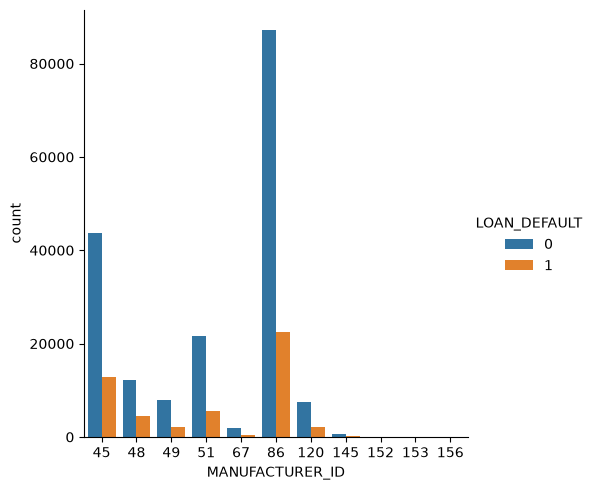

In [53]:
#plot MANUFACTURER_ID with LOAN_DEFAULT
sns.catplot(data=df2_loan,kind='count',x='MANUFACTURER_ID',hue='LOAN_DEFAULT')

In [54]:
#explore categorical function
def explore_categorical(col_name):
    #print statistical summary
    print("{0} Summary".format(col_name))
    print("\n")
    
    print("{0} Counts".format(col_name))
    print(df2_loan[col_name].value_counts())
    print("\n")

    print("{0} Ratio".format(col_name))
    print(df2_loan[col_name].value_counts(normalize=True))
    print("\n")

    print("{0} Default Counts".format(col_name))
    print(df2_loan.groupby(col_name)['LOAN_DEFAULT'].value_counts().unstack(level=-1))
    print("\n")

    print("{0} Default Ratio".format(col_name))
    print(df2_loan.groupby(col_name)['LOAN_DEFAULT'].value_counts().unstack(level=-1))
    print("\n")

    sns.catplot(data=df2_loan,kind='count',x=col_name,hue='LOAN_DEFAULT')
    plt.show()

DISBURSAL_MONTH Summary


DISBURSAL_MONTH Counts
DISBURSAL_MONTH
10    98364
8     68002
9     66788
Name: count, dtype: int64


DISBURSAL_MONTH Ratio
DISBURSAL_MONTH
10    0.421884
8     0.291661
9     0.286454
Name: proportion, dtype: float64


DISBURSAL_MONTH Default Counts
LOAN_DEFAULT         0      1
DISBURSAL_MONTH              
8                53336  14666
9                53973  12815
10               75234  23130


DISBURSAL_MONTH Default Ratio
LOAN_DEFAULT         0      1
DISBURSAL_MONTH              
8                53336  14666
9                53973  12815
10               75234  23130




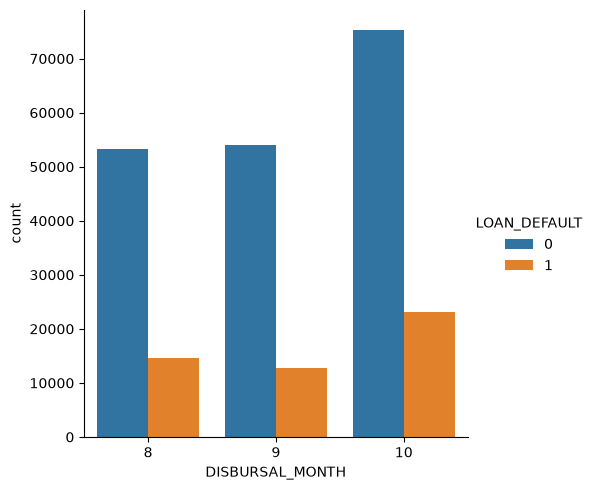

In [55]:
#explore DISBURSAL_MONTH
explore_categorical('DISBURSAL_MONTH')

In [56]:
#Age Summary
df2_loan["AGE"].describe()

count    233154.000000
mean         33.954142
std           9.821186
min          18.000000
25%          26.000000
50%          32.000000
75%          41.000000
max          69.000000
Name: AGE, dtype: float64

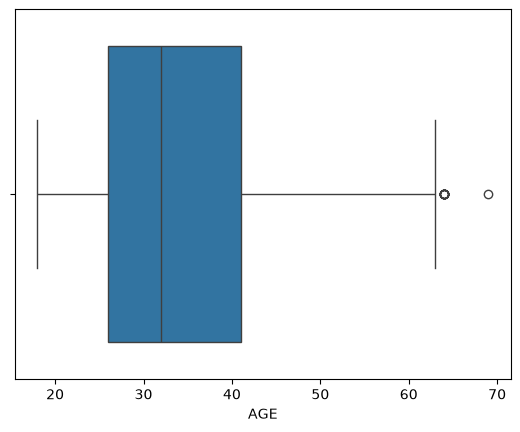

In [57]:
#age boxplot
sns.boxplot(x="AGE", data=df2_loan)
plt.show()

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1561809903.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2_loan['AGE'], hist=False)


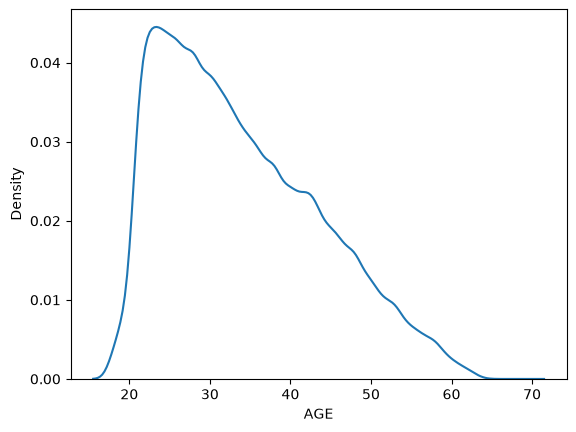

In [58]:
#age distplot
sns.distplot(df2_loan['AGE'], hist=False)
plt.show()

In [59]:
#age summary grouped by LOAN_DEFAULT
df2_loan.groupby('LOAN_DEFAULT')['AGE'].describe()

,count,mean,std,min,25%,50%,75%,max
LOAN_DEFAULT,,,,,,,,
0,182543.0,34.143150,9.853115,18.0,26.0,32.0,41.0,69.0
1,50611.0,33.272431,9.674619,18.0,25.0,31.0,40.0,64.0


/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/2931976934.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AGE', y='LOAN_DEFAULT', data=df2_loan, palette="rocket", orient="h")


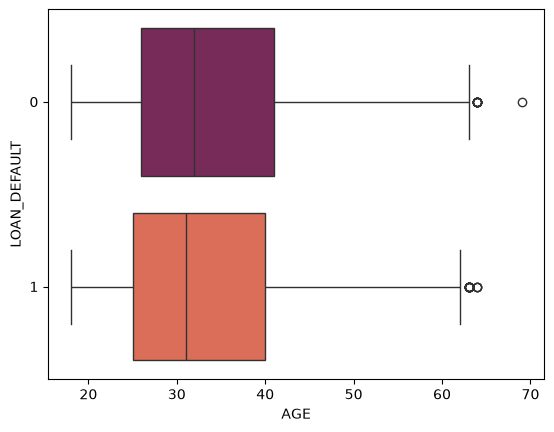

In [60]:
#age boxplot grouped by loan default
sns.boxplot(x='AGE', y='LOAN_DEFAULT', data=df2_loan, palette="rocket", orient="h")
plt.show()

In [61]:
#explore continuous function
def explore_continuous(col_name):
    #print statistical summary
    print("{0} Summary".format(col_name))
    print("\n")
    print(df2_loan[col_name].describe())
    print("\n")

    #look at boxplot
    sns.boxplot(x=col_name, data=df2_loan)
    plt.show()

    #look at the distribution
    sns.distplot(df2_loan[col_name], hist=False)
    plt.show()

    #now lets look deeper by grouping with the target variable           
    print("{0} Grouped Summary".format(col_name))
    print("\n")
    print(df2_loan.groupby('LOAN_DEFAULT')[col_name].describe())
    #look at grouped boxplot
    sns.boxplot(x=col_name, y='LOAN_DEFAULT', data=df2_loan, orient="h")
    plt.show()

DISBURSED_AMOUNT Summary


count    233154.000000
mean      54356.993528
std       12971.314171
min       13320.000000
25%       47145.000000
50%       53803.000000
75%       60413.000000
max      990572.000000
Name: DISBURSED_AMOUNT, dtype: float64




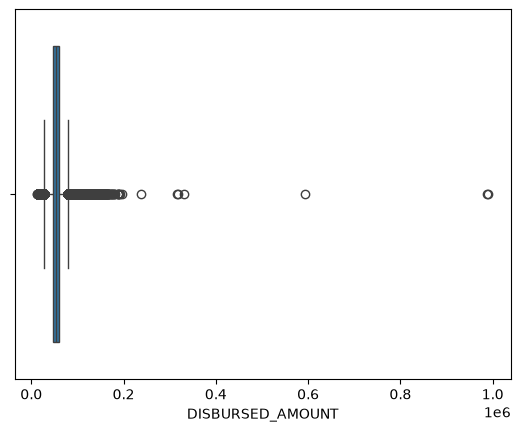

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/3483606542.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2_loan[col_name], hist=False)


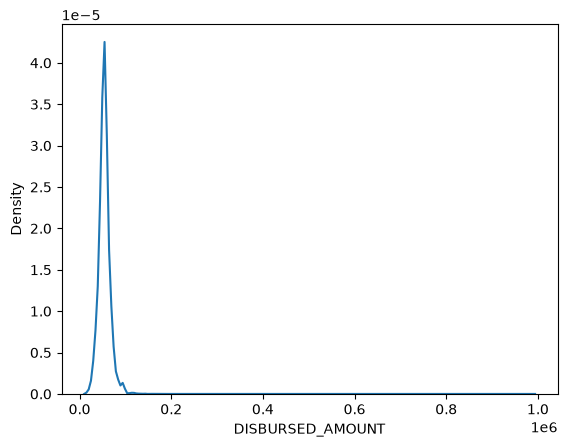

DISBURSED_AMOUNT Grouped Summary


                 count          mean           std      min      25%      50%  \
LOAN_DEFAULT                                                                    
0             182543.0  53826.471111  13140.699007  13320.0  46369.0  53303.0   
1              50611.0  56270.473869  12150.255527  13369.0  49303.0  55459.0   

                  75%       max  
LOAN_DEFAULT                     
0             59947.0  990572.0  
1             61947.0  191392.0  


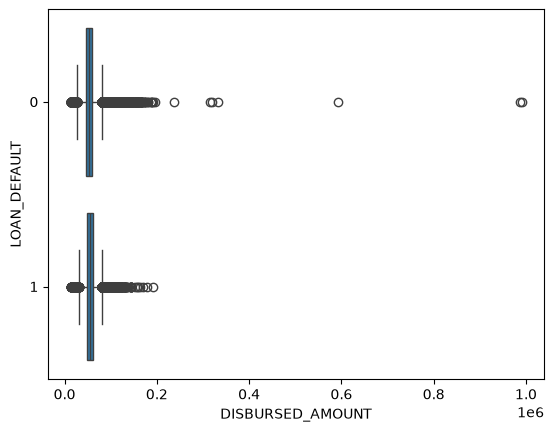

In [62]:
explore_continuous('DISBURSED_AMOUNT')

In [63]:
#explore_categorical function to look at data with binary or boolean fields such as 'AADHAR_FLAG'
#1 means a piece of personal information was given by customer and o means it was not.

AADHAR_FLAG Summary


AADHAR_FLAG Counts
AADHAR_FLAG
1    195924
0     37230
Name: count, dtype: int64


AADHAR_FLAG Ratio
AADHAR_FLAG
1    0.84032
0    0.15968
Name: proportion, dtype: float64


AADHAR_FLAG Default Counts
LOAN_DEFAULT       0      1
AADHAR_FLAG                
0              27684   9546
1             154859  41065


AADHAR_FLAG Default Ratio
LOAN_DEFAULT       0      1
AADHAR_FLAG                
0              27684   9546
1             154859  41065




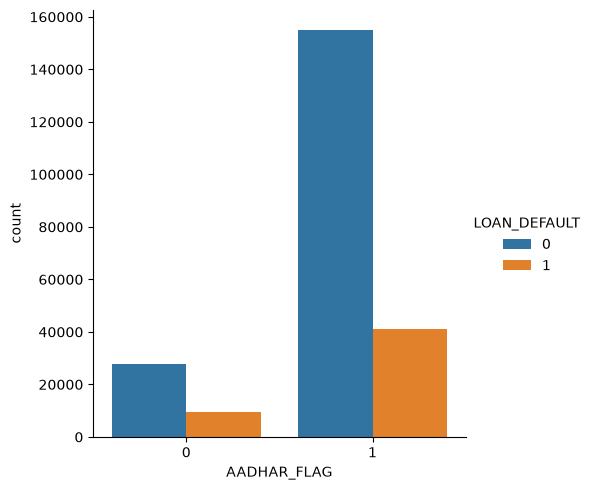

In [64]:
#explore AADHAR_FLAG
explore_categorical('AADHAR_FLAG')

In [65]:
#save exploratory data analysis as new file
df2_loan.to_csv('/Users/evansamoah/Desktop/Projects/Python/Loan Default Prediction/vehicleloans_eda.csv')

In [66]:
# FEATURE ENGINEERING

In [67]:
from sklearn.preprocessing import MinMaxScaler

In [68]:
df2_loan = pd.read_csv('/Users/evansamoah/Desktop/Projects/Python/Loan Default Prediction/vehicleloans_eda.csv')

In [69]:
#LETS USE IDXMAX FUNCTION TO FIND THE INDEX OF THE ROW WITH THE MAXIMUM VALUE OF A COLUMN
#get row index of max disbursed amount

In [70]:
df2_loan['DISBURSED_AMOUNT'].idxmax()

210252

In [71]:
#WE HAVE THE ROW INDEX BUT WE HAVE TO SELECT THE ROW
# DATAFRAME ROWS CAN BE SELECTED BY THEIR INDEX USING THE LOC FUNCTION

In [72]:
#useing idxmax to get row
df2_loan.loc[df2_loan['DISBURSED_AMOUNT'].idxmax()]

UNIQUEID                                                                          440173
DISBURSED_AMOUNT                                                                  990572
ASSET_COST                                                                       1628992
LTV                                                                                61.39
MANUFACTURER_ID                                                                      152
EMPLOYMENT_TYPE                                                                  Missing
STATE_ID                                                                               9
AADHAR_FLAG                                                                            1
PAN_FLAG                                                                               1
VOTERID_FLAG                                                                           0
DRIVING_FLAG                                                                           0
PASSPORT_FLAG        

In [73]:
#KEEPING EXTREME VALUES WITHOUT THEM SKEWING THE DATA IS THROUGH BINNING
#CREATING CATEGORICAL GROUPS FROM CONNTINUOUS VARIABLES
#CREATING SOME BINS BASED ON THE DISBURSED AMOUNT

In [74]:
#create buckets for disbursed amount
disbursed_buckets = [13000, 30000, 45000, 60000, 75000, 150000, 1000000]
disbursed_labels = ['13k - 30k', '30k - 45k', '45k - 60k', '60k - 75k', '75k - 150k', '150k - 1m']

In [75]:
#WE WILL NOW USE THESE BINS TO CATEGORIZE OUR ROWS BASED ON DISBURSED AMOUNTS
#PANDAS PROVIDES THE CUTS WHICH ALLOWS US TO CREATE BUCKETS AND LABELS

In [76]:
#use cut to assign rows to new buckets
df2_loan['DISBURSED_CAT'] = pd.cut(df2_loan['DISBURSED_AMOUNT'], disbursed_buckets, labels=disbursed_labels)

In [77]:
#explore new variable

DISBURSED_CAT Summary


DISBURSED_CAT Counts
DISBURSED_CAT
45k - 60k     126904
60k - 75k      49824
30k - 45k      40626
75k - 150k     10871
13k - 30k       4865
150k - 1m         64
Name: count, dtype: int64


DISBURSED_CAT Ratio
DISBURSED_CAT
45k - 60k     0.544293
60k - 75k     0.213696
30k - 45k     0.174245
75k - 150k    0.046626
13k - 30k     0.020866
150k - 1m     0.000274
Name: proportion, dtype: float64


DISBURSED_CAT Default Counts
LOAN_DEFAULT       0      1
DISBURSED_CAT              
13k - 30k       4207    658
30k - 45k      34323   6303
45k - 60k      98830  28074
60k - 75k      37056  12768
75k - 150k      8070   2801
150k - 1m         57      7


DISBURSED_CAT Default Ratio
LOAN_DEFAULT       0      1
DISBURSED_CAT              
13k - 30k       4207    658
30k - 45k      34323   6303
45k - 60k      98830  28074
60k - 75k      37056  12768
75k - 150k      8070   2801
150k - 1m         57      7




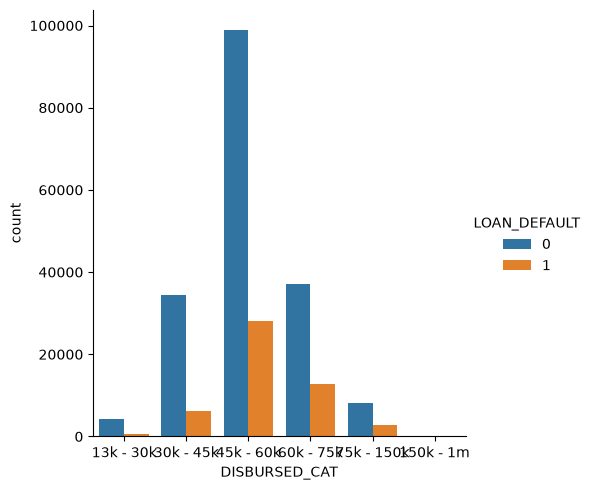

In [78]:
explore_categorical('DISBURSED_CAT')

In [79]:
#DISBURSAL DIFFERENCE
#CREATING NEW FEATURES AND COLUMNS FROM EXISTING ONES

In [80]:
#calculate disbursal difference
df2_loan['DISBURSAL_DIFFERENCE'] = df2_loan['ASSET_COST'] - df2_loan['DISBURSED_AMOUNT']

In [81]:
df2_loan[['DISBURSAL_DIFFERENCE', 'ASSET_COST', 'DISBURSED_AMOUNT']].sample(5)

,DISBURSAL_DIFFERENCE,ASSET_COST,DISBURSED_AMOUNT
164896,34643,71082,36439
54526,11464,65844,54380
48496,36142,64671,28529
43398,11744,61322,49578
229664,40183,111699,71516


In [82]:
#COMBINING PRIMARY AND SECONDARY ACCOUNTS
#a primary account is a loan where the customer is the sole recipient of the disbursal, 
#a secondary account is one where the customer is a co-applicant or guarantor for the loan 

In [83]:
df2_loan['TOTAL_ACCTS'] = df2_loan['PRI_NO_OF_ACCTS'] + df2_loan['SEC_NO_OF_ACCTS']

In [84]:
df2_loan[['TOTAL_ACCTS', 'PRI_NO_OF_ACCTS', 'SEC_NO_OF_ACCTS']].sample(10)

,TOTAL_ACCTS,PRI_NO_OF_ACCTS,SEC_NO_OF_ACCTS
134850,2,2,0
5865,1,1,0
194366,1,1,0
105674,3,3,0
127263,0,0,0
169478,3,3,0
137737,0,0,0
208102,7,4,3
179179,0,0,0
98541,2,2,0


In [85]:
#TOTAL_ columns from the remaining primary/secondary variables

In [86]:
df2_loan['TOTAL_ACTIVE_ACCTS'] = df2_loan['PRI_ACTIVE_ACCTS'] + df2_loan['SEC_ACTIVE_ACCTS']
df2_loan['TOTAL_OVERDUE_ACCTS'] = df2_loan['PRI_OVERDUE_ACCTS'] + df2_loan['SEC_OVERDUE_ACCTS']
df2_loan['TOTAL_CURRENT_BALANCE'] = df2_loan['PRI_CURRENT_BALANCE'] + df2_loan['SEC_CURRENT_BALANCE']
df2_loan['TOTAL_SANCTIONED_AMOUNT'] = df2_loan['PRI_SANCTIONED_AMOUNT'] + df2_loan['SEC_SANCTIONED_AMOUNT'] 
df2_loan['TOTAL_DISBURSED_AMOUNT'] = df2_loan['PRI_DISBURSED_AMOUNT'] + df2_loan['SEC_DISBURSED_AMOUNT']
df2_loan['TOTAL_INSTAL_AMT'] = df2_loan['PRIMARY_INSTAL_AMT'] + df2_loan['SEC_INSTAL_AMT']

In [87]:
#we have simplified our dataset by combining the primary and secondary account columns 
#Let's drop the ones we no longer need to avoid data duplication

In [88]:
drop_cols = ['PRI_NO_OF_ACCTS', 'PRI_ACTIVE_ACCTS', 'PRI_OVERDUE_ACCTS', 'PRI_CURRENT_BALANCE', 'PRI_SANCTIONED_AMOUNT', 'PRI_DISBURSED_AMOUNT', 'PRIMARY_INSTAL_AMT', 'SEC_NO_OF_ACCTS', 'SEC_ACTIVE_ACCTS', 'SEC_OVERDUE_ACCTS', 'SEC_CURRENT_BALANCE', 'SEC_SANCTIONED_AMOUNT', 'SEC_DISBURSED_AMOUNT', 'SEC_INSTAL_AMT']

df2_loan = df2_loan.drop(drop_cols, axis=1)

In [89]:
#Creating a column 'OVERDUE_PCT' that stores the percentage of overdue accounts
df2_loan['OVERDUE_PCT'] = df2_loan['TOTAL_OVERDUE_ACCTS'] / df2_loan['TOTAL_ACCTS']

In [90]:
#checking this new column for missing values, remember a lot of rows will have 0 'TOTAL_ACCTS'

#We can investigate using isnull and sum

In [91]:
df2_loan['OVERDUE_PCT'].isnull().sum()

np.int64(115792)

In [92]:
#Filling missing values with na
df2_loan['OVERDUE_PCT'] = df2_loan['OVERDUE_PCT'].fillna(0)

In [93]:
#Let's use isnull and sum again to make sure we no longer have missing values
df2_loan['OVERDUE_PCT'].isnull().sum()

np.int64(0)

In [94]:
df2_loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 32 columns):
 #   Column                               Non-Null Count   Dtype   
---  ------                               --------------   -----   
 0   UNIQUEID                             233154 non-null  int64   
 1   DISBURSED_AMOUNT                     233154 non-null  int64   
 2   ASSET_COST                           233154 non-null  int64   
 3   LTV                                  233154 non-null  float64 
 4   MANUFACTURER_ID                      233154 non-null  int64   
 5   EMPLOYMENT_TYPE                      233154 non-null  str     
 6   STATE_ID                             233154 non-null  int64   
 7   AADHAR_FLAG                          233154 non-null  int64   
 8   PAN_FLAG                             233154 non-null  int64   
 9   VOTERID_FLAG                         233154 non-null  int64   
 10  DRIVING_FLAG                         233154 non-null  int64   
 11  PASSPORT_FL

In [95]:
#We will use min max scaling to bring our continuous variables into the same range
#Outliers have been observed in the data. However, we will keep them as they appear to be legitimate
#Sklearn provides an implementation of Min Max scaling, MinMaxScaler

In [96]:
#First, we create a list of our continuous columns
#We can use this list to select the continuous variables from our dataframe without typing a long list of column names each time
#We don't need to scale our categoricals or binaries


In [97]:
numeric_cols = ['DISBURSED_AMOUNT', 
                'ASSET_COST', 
                'LTV', 
                'NEW_ACCTS_IN_LAST_SIX_MONTHS', 
                'DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS', 
                'NO_OF_INQUIRIES', 
                'AGE', 
                'AVERAGE_ACCT_AGE_MONTHS', 
                'CREDIT_HISTORY_LENGTH_MONTHS',
                'PERFORM_CNS_SCORE',
                'TOTAL_ACCTS',
                'TOTAL_ACTIVE_ACCTS',
                'TOTAL_OVERDUE_ACCTS',
                'TOTAL_CURRENT_BALANCE', 
                'TOTAL_SANCTIONED_AMOUNT', 
                'TOTAL_DISBURSED_AMOUNT', 
                'TOTAL_INSTAL_AMT', 
                'OVERDUE_PCT', 
                'DISBURSAL_DIFFERENCE']

In [98]:
#Let's look at the numeric columns so we have a reference.

#We can plot multiple columns on the same plot using pandas boxplot

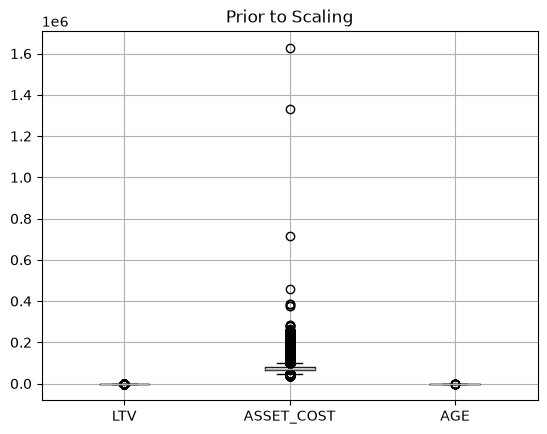

In [99]:
df2_loan[['LTV', 'ASSET_COST', 'AGE']].boxplot()
plt.title('Prior to Scaling')
plt.show()

In [100]:
#Observe that the numeric values are distributed across very different scales.

#Let's fix this problem using Min Max Scaling.

#First we need to create an instance of MinMaxScaler 

In [101]:
mm_scaler = MinMaxScaler()

In [102]:
#We can use fit_transform to fit the scaler to our data and perform the scaling

In [103]:
df2_loan[numeric_cols] = mm_scaler.fit_transform(df2_loan[numeric_cols])

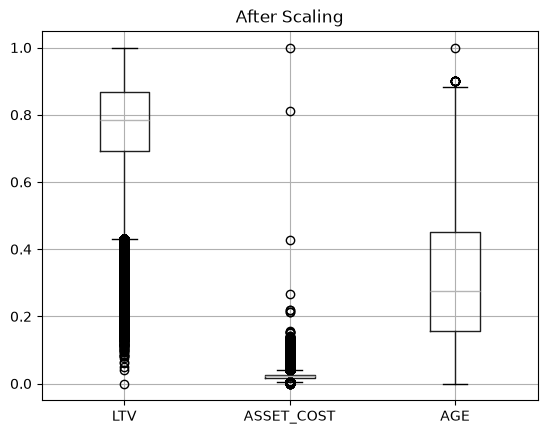

In [104]:
df2_loan[['LTV', 'ASSET_COST', 'AGE']].boxplot()
plt.title('After Scaling')
plt.show()

In [105]:
#save feature engineering as new file
df2_loan.to_csv('/Users/evansamoah/Desktop/Projects/Python/Loan Default Prediction/vehicleloans_feateng.csv')

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, roc_curve, auc, precision_score, ConfusionMatrixDisplay

In [107]:
df2_loan = pd.read_csv('/Users/evansamoah/Desktop/Projects/Python/Loan Default Prediction/vehicleloans_feateng.csv', index_col ='UNIQUEID')

In [108]:
df2_loan.info()

<class 'pandas.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 32 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Unnamed: 0                           233154 non-null  int64  
 1   DISBURSED_AMOUNT                     233154 non-null  float64
 2   ASSET_COST                           233154 non-null  float64
 3   LTV                                  233154 non-null  float64
 4   MANUFACTURER_ID                      233154 non-null  int64  
 5   EMPLOYMENT_TYPE                      233154 non-null  str    
 6   STATE_ID                             233154 non-null  int64  
 7   AADHAR_FLAG                          233154 non-null  int64  
 8   PAN_FLAG                             233154 non-null  int64  
 9   VOTERID_FLAG                         233154 non-null  int64  
 10  DRIVING_FLAG                         233154 non-null  int64  
 11  PASSPORT_FLAG           

In [109]:
# look at categorical data types
category_cols = ['MANUFACTURER_ID', 'STATE_ID', 'DISBURSAL_MONTH', 'DISBURSED_CAT', 'PERFORM_CNS_SCORE_DESCRIPTION', 'EMPLOYMENT_TYPE']
df2_loan[category_cols].dtypes

MANUFACTURER_ID                  int64
STATE_ID                         int64
DISBURSAL_MONTH                  int64
DISBURSED_CAT                      str
PERFORM_CNS_SCORE_DESCRIPTION      str
EMPLOYMENT_TYPE                    str
dtype: object

In [110]:
#convert to categorical type
df2_loan[category_cols] = df2_loan[category_cols].astype('category')
df2_loan[category_cols].dtypes

MANUFACTURER_ID                  category
STATE_ID                         category
DISBURSAL_MONTH                  category
DISBURSED_CAT                    category
PERFORM_CNS_SCORE_DESCRIPTION    category
EMPLOYMENT_TYPE                  category
dtype: object

In [111]:
#small columns variables in separate data frame
small_cols = ['STATE_ID', 'LTV', 'DISBURSED_CAT', 'PERFORM_CNS_SCORE', 'DISBURSAL_MONTH', 'LOAN_DEFAULT']
df2_loan_sml = df2_loan[small_cols]

In [112]:
df2_loan_sml.shape

(233154, 6)

In [113]:
df2_loan_sml.info()

<class 'pandas.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   STATE_ID           233154 non-null  category
 1   LTV                233154 non-null  float64 
 2   DISBURSED_CAT      233154 non-null  category
 3   PERFORM_CNS_SCORE  233154 non-null  float64 
 4   DISBURSAL_MONTH    233154 non-null  category
 5   LOAN_DEFAULT       233154 non-null  int64   
dtypes: category(3), float64(2), int64(1)
memory usage: 7.8 MB


In [114]:
#creating two variables x and y to match the required parameters for train test split
x = df2_loan_sml.drop(['LOAN_DEFAULT'], axis=1)
y = df2_loan_sml['LOAN_DEFAULT']

In [115]:
#check the rows and columns
print("x has {0} rows and {1} columns".format(x.shape[0], x.shape[1]))
print("y has {0} rows".format(y.count()))

x has 233154 rows and 5 columns
y has 233154 rows


In [116]:
#x info
x.info()

<class 'pandas.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   STATE_ID           233154 non-null  category
 1   LTV                233154 non-null  float64 
 2   DISBURSED_CAT      233154 non-null  category
 3   PERFORM_CNS_SCORE  233154 non-null  float64 
 4   DISBURSAL_MONTH    233154 non-null  category
dtypes: category(3), float64(2)
memory usage: 6.0 MB


In [117]:
#y info
y.dtype

dtype('int64')

In [118]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [119]:
#check rows and columns
print("x_train has {0} rows and {1} columns".format(x_train.shape[0], x_train.shape[1]))
print("x_train has {0} rows and {1} columns".format(x_test.shape[0], x_test.shape[1]))
print("y_train has {0} rows".format(y_train.count()))
print("y_test has {0} rows".format(y_test.count()))

x_train has 186523 rows and 5 columns
x_train has 46631 rows and 5 columns
y_train has 186523 rows
y_test has 46631 rows


In [120]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 186523 entries, 633275 to 501520
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   STATE_ID           186523 non-null  category
 1   LTV                186523 non-null  float64 
 2   DISBURSED_CAT      186523 non-null  category
 3   PERFORM_CNS_SCORE  186523 non-null  float64 
 4   DISBURSAL_MONTH    186523 non-null  category
dtypes: category(3), float64(2)
memory usage: 4.8 MB


In [121]:
y_train.head()

UNIQUEID
633275    1
646002    0
591252    0
475736    0
639478    0
Name: LOAN_DEFAULT, dtype: int64

In [122]:
x_test.info()

<class 'pandas.DataFrame'>
Index: 46631 entries, 617183 to 626383
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   STATE_ID           46631 non-null  category
 1   LTV                46631 non-null  float64 
 2   DISBURSED_CAT      46631 non-null  category
 3   PERFORM_CNS_SCORE  46631 non-null  float64 
 4   DISBURSAL_MONTH    46631 non-null  category
dtypes: category(3), float64(2)
memory usage: 1.2 MB


In [123]:
y_test.head()

UNIQUEID
617183    1
515702    0
466872    0
632384    0
461426    0
Name: LOAN_DEFAULT, dtype: int64

In [124]:
#check the training target variable
y_train.value_counts(normalize=True)

LOAN_DEFAULT
0    0.783099
1    0.216901
Name: proportion, dtype: float64

In [125]:
#initialize the model
logistic_model = LogisticRegression()

In [126]:
#one hot encode
#df2_loan_sml is small dataframe we want to encode
#prefix_sep is separator for dummy variables, new columns will be created
#drop_first drop one dummy column where a boolean variable does't belong one of 9 category
loan_data_dummy = pd.get_dummies(df2_loan_sml, prefix_sep='_', drop_first=True)

In [127]:
loan_data_dummy.info()

<class 'pandas.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 31 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   LTV                       233154 non-null  float64
 1   PERFORM_CNS_SCORE         233154 non-null  float64
 2   LOAN_DEFAULT              233154 non-null  int64  
 3   STATE_ID_2                233154 non-null  bool   
 4   STATE_ID_3                233154 non-null  bool   
 5   STATE_ID_4                233154 non-null  bool   
 6   STATE_ID_5                233154 non-null  bool   
 7   STATE_ID_6                233154 non-null  bool   
 8   STATE_ID_7                233154 non-null  bool   
 9   STATE_ID_8                233154 non-null  bool   
 10  STATE_ID_9                233154 non-null  bool   
 11  STATE_ID_10               233154 non-null  bool   
 12  STATE_ID_11               233154 non-null  bool   
 13  STATE_ID_12               233154 non-null  bool   
 14 

In [128]:
#recreate training and test set using loan_data dummy
x = loan_data_dummy.drop(['LOAN_DEFAULT'], axis=1)
y = loan_data_dummy['LOAN_DEFAULT']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

LOAN_DEFAULT
0    0.782975
1    0.217025
Name: proportion, dtype: float64
LOAN_DEFAULT
0    0.782821
1    0.217179
Name: proportion, dtype: float64


In [129]:
#initialize and train logistic regression
#fit model
logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [130]:
#generate predictions
preds = logistic_model.predict(x_test)
preds

array([0, 0, 0, ..., 0, 0, 0], shape=(69947,))

In [131]:
#get accuracy
logistic_model.score(x_test, y_test)

0.7828355755071698

In [132]:
#simple logistic regression model
category_cols = ['MANUFACTURER_ID', 'STATE_ID', 'DISBURSAL_MONTH', 'DISBURSED_CAT', 'PERFORM_CNS_SCORE_DESCRIPTION', 'EMPLOYMENT_TYPE']

df2_loan[category_cols] = df2_loan[category_cols].astype('category')

In [133]:
small_cols = ['STATE_ID', 'LTV', 'DISBURSED_CAT', 'PERFORM_CNS_SCORE_DESCRIPTION', 'DISBURSAL_MONTH', 'LOAN_DEFAULT']
df2_loan_sml = df2_loan[small_cols]

loan_data_dummy = pd.get_dummies(df2_loan_sml, prefix_sep='_', drop_first=True)

x = loan_data_dummy.drop(['LOAN_DEFAULT'], axis=1)
y = loan_data_dummy['LOAN_DEFAULT']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [134]:
#get model accuracy
logistic_model.score(x_test, y_test)

0.7821835259805708

In [135]:
#get model predictions 
preds = logistic_model.predict(x_test)
preds

array([0, 0, 0, ..., 0, 0, 0], shape=(46631,))

In [136]:
#confusion matrix
conf_mat = confusion_matrix(y_test, preds)
conf_mat

array([[36469,     8],
       [10149,     5]])

In [137]:
#confusion matrix returns a 2d array of TN, FP, FN & TP
tn = conf_mat[0][0]
fp = conf_mat[0][1]
fn = conf_mat[1][0]
tp = conf_mat[1][1]

In [138]:
#print values
print("True Negatives (Correct Non-Defaults): ", tn)
print("False Positives (Incorrect Defaults): ", fp)
print("False Negatives (Incorrect Non-Defaults): ", fn)
print("True Positives (Correct Defaults)", tp) 

True Negatives (Correct Non-Defaults):  36469
False Positives (Incorrect Defaults):  8
False Negatives (Incorrect Non-Defaults):  10149
True Positives (Correct Defaults) 5


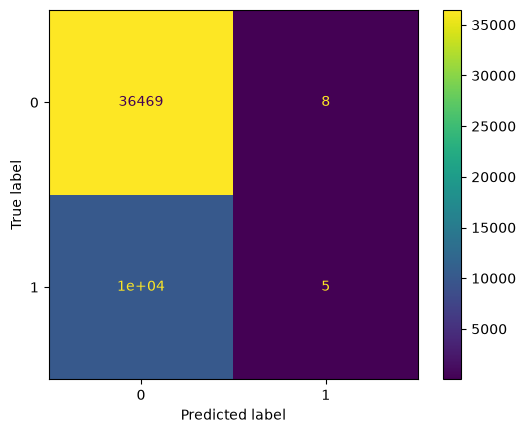

In [139]:
#plot confusion matrix
y_pred = logistic_model.predict(x_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [140]:
#get precision
precision = precision_score(y_test, y_pred)
precision

0.38461538461538464

In [141]:
#get recall
#RECALL = TP/TP + FN
#Useful when the cost negatives is high that is in disease detection

In [142]:
recall = recall_score(y_test, preds)
recall 

0.0004924167815639157

In [143]:
#get F1 Score
#useful when we need a balance between precision and recall
#less affected by large numbers of true negatives than accuracy
# f1 score takes 2 parameters test labels and predicted labels

In [144]:
f1 = f1_score(y_test, preds)
f1

0.000983574309039048

In [145]:
#get predicted probabilities
probs = logistic_model.predict_proba(x_test)
probs

array([[0.62386224, 0.37613776],
       [0.82503102, 0.17496898],
       [0.70457238, 0.29542762],
       ...,
       [0.79027772, 0.20972228],
       [0.90498213, 0.09501787],
       [0.79990176, 0.20009824]], shape=(46631, 2))

In [146]:
probs.shape

(46631, 2)

In [147]:
#get columns
print(probs[:,0])
print(probs[:,1])

[0.62386224 0.82503102 0.70457238 ... 0.79027772 0.90498213 0.79990176]
[0.37613776 0.17496898 0.29542762 ... 0.20972228 0.09501787 0.20009824]


In [148]:
#create dataframe to store predictive probabilities
probs_df = pd.DataFrame()
probs_df['prob_0'] = probs[:, 0]
probs_df['prob_1'] = probs[:, 1]

probs_df.describe()

,prob_0,prob_1
count,46631.000000,46631.000000
mean,0.783415,0.216585
std,0.074253,0.074253
min,0.411688,0.032889
25%,0.735506,0.162374
50%,0.787749,0.212251
75%,0.837626,0.264494
max,0.967111,0.588312


In [149]:
#roc
#the roc curve function returns 3 values, threshold, false positive rate and true positive rate
fpr, tpr, threshold = roc_curve(y_test, probs[:,1], pos_label=1)

In [150]:
#roc results
print("FPR: ", fpr)
print("TPR: ", tpr)
print("Threshold: ", threshold)

FPR:  [0.00000000e+00 2.74145352e-05 5.48290704e-05 ... 9.99616197e-01
 9.99616197e-01 1.00000000e+00]
TPR:  [0.         0.         0.         ... 0.99990152 1.         1.        ]
Threshold:  [       inf 0.58831196 0.54187563 ... 0.04700228 0.04699648 0.03288929]


In [151]:
#roc dataframe
roc_df = pd.DataFrame()
roc_df['fpr'] = fpr
roc_df['tpr'] = tpr
roc_df['threshold'] = threshold

roc_df.describe()

/opt/anaconda3/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,fpr,tpr,threshold
count,16849.000000,16849.000000,1.684900e+04
mean,0.405697,0.528594,inf
std,0.272168,0.285675,NaN
min,0.000000,0.000000,3.288929e-02
25%,0.168956,0.288261,1.830131e-01
50%,0.373002,0.541560,2.294093e-01
75%,0.615895,0.776246,2.800277e-01
max,1.000000,1.000000,inf


In [152]:
#auc
#the auc function takes two parameters the fpr and tpr from roc curve
roc_auc = auc(fpr, tpr)
print("AUC: ", roc_auc)

AUC:  0.6202374015051016


In [153]:
#plot roc curve
def plot_roc_curve(fpr, tpr, roc_auc):
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0,1], [0,1], 'r--')
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

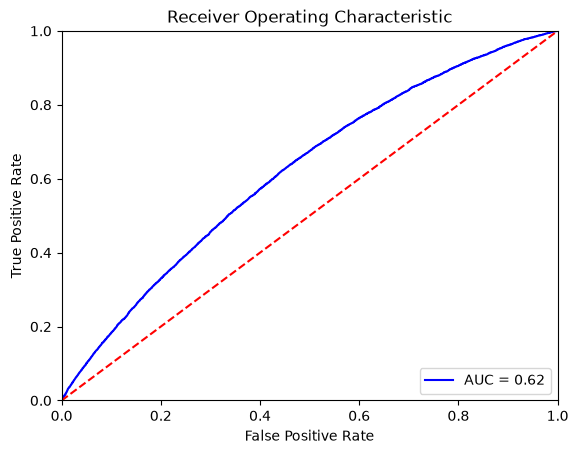

In [154]:
plot_roc_curve(fpr, tpr, roc_auc)

In [155]:
#results dataframe
results_df = pd.DataFrame()
results_df['true_class'] = y_test
results_df['predicted_class'] = list(preds)
results_df['default_prob'] = probs[:, 1]

In [156]:
#class prediction percentages
#using df.groupby and value counts to print
#what percentage 1s were predicted as 1s (TPR)
#what percentage of 1s were predicted as 0s (FNR)
#what percentage of 0s were predicted as 0s (TNR)
#what percentage of 0s were predicted as 1s (FPR)

In [157]:
results_df.groupby('true_class')['predicted_class'].value_counts(normalize=True)

true_class  predicted_class
0           0                  0.999781
            1                  0.000219
1           0                  0.999508
            1                  0.000492
Name: proportion, dtype: float64

In [158]:
#class probability distributions
#we can use results_df to plot the class probability distributions
#the code used to get the predicted default probability of all the non-defaulted loans

In [159]:
#default probs
default_probs_f = results_df[results_df['true_class'] == 0]['default_prob']

In [160]:
#using pandas filtering to create a variable default_probs_t which contains 
# the predicted default probability for all true defaulted loans

In [161]:
default_probs_t = results_df[results_df['true_class'] == 1]['default_prob']

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/2903393463.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(default_probs_f, label='Non Default', hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/2903393463.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad63727

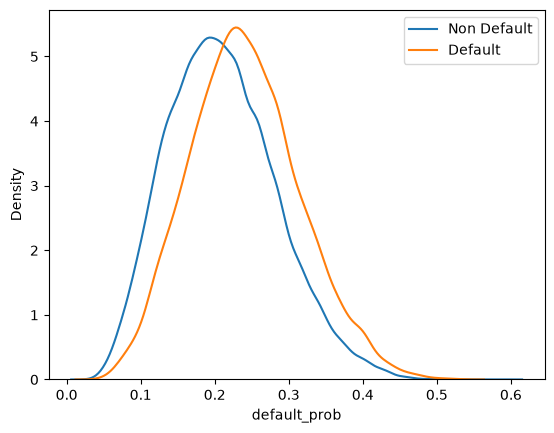

In [162]:
#plot distributions
sns.distplot(default_probs_f, label='Non Default', hist=False)
sns.distplot(default_probs_t, label='Default', hist=False)
plt.legend(loc = 'best')
plt.show()

In [163]:
def eval_model(model, x_test, y_test):
# Store discrete predictions and probabilities separately
    preds = model.predict(x_test)
    probs = model.predict_proba(x_test)

# Calculate classification metrics using predicted class labels
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

# Plot Confusion Matrix (expects true labels first, then predicted labels)
    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.show()

    print("\n")
    print("Accuracy: ", accuracy)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1: ", f1)

# ROC Curve using positive class probabilities
    fpr, tpr, threshold = roc_curve(y_test, probs[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    print("AUC: ", roc_auc)

# Note: Ensure plot_roc_curve is defined or use standard matplotlib plot
# plot_roc_curve(fpr, tpr, roc_auc)
    plot_roc_curve(fpr, tpr, roc_auc)

    results_df = pd.DataFrame()
    results_df['true_class'] = y_test
    results_df['predicted_class'] = list(preds)
    results_df['default_prob'] = probs[:, 1]
    

# Construct results DataFrame
    results_df = pd.DataFrame()
    results_df['true_class'] = list(y_test)
    results_df['predicted_class'] = list(preds)
    results_df['default_prob'] = probs[:, 1]

# Plot probability distributions
    sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
    sns.distplot(results_df[results_df['true_class'] == 1]['default_prob'], label="Default", hist=False)
    plt.show()

# See true class vs predicted class as percentage
    print(results_df.groupby('true_class')['predicted_class'].value_counts(normalize=True))


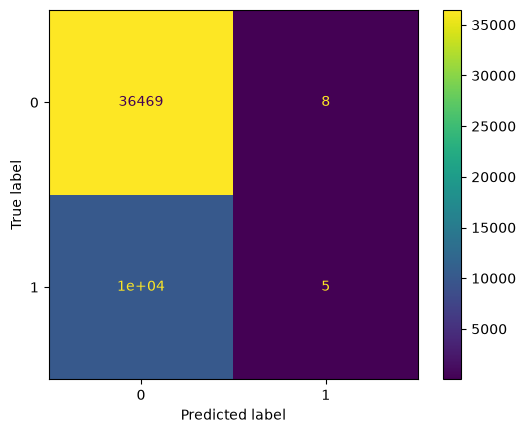



Accuracy:  0.7821835259805708
Precision:  0.38461538461538464
Recall:  0.0004924167815639157
F1:  0.000983574309039048
AUC:  0.6202374015051016


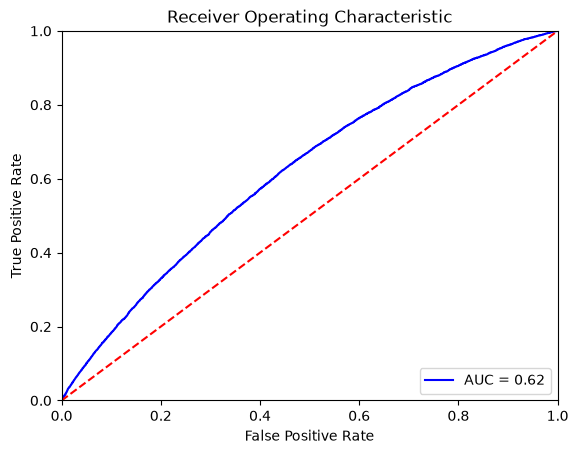

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

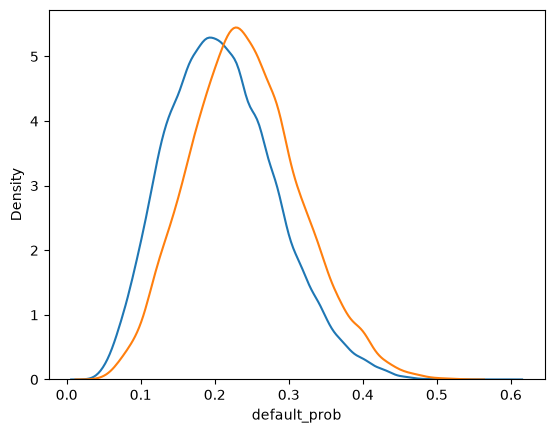

true_class  predicted_class
0           0                  0.999781
            1                  0.000219
1           0                  0.999508
            1                  0.000492
Name: proportion, dtype: float64


In [164]:
eval_model(logistic_model, x_test, y_test)

In [165]:
#importing Random Forest Classifier from Sklearn
from sklearn.ensemble import RandomForestClassifier

In [166]:
#Creating a training and test set for random forest
def encode_and_split(df2_loan):
    loan_data_dummy = pd.get_dummies(df2_loan, prefix_sep='_', drop_first=True)

    x = loan_data_dummy.drop(['LOAN_DEFAULT'], axis=1)
    y = loan_data_dummy['LOAN_DEFAULT']

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    return x_train, x_test, y_train, y_test

In [167]:
x_train, x_test, y_train, y_test = encode_and_split(df2_loan)

In [168]:
#get training shape
print("Training Features Shape", x_train.shape)
print("Training Label Rows", y_train.count())

Training Features Shape (186523, 84)
Training Label Rows 186523


In [169]:
#get testing shape
print("Testing Features Shape", x_test.shape)
print("Testing Label Rows", y_test.count())

Testing Features Shape (46631, 84)
Testing Label Rows 46631


In [170]:
#check Class Distribution
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

LOAN_DEFAULT
0    0.783099
1    0.216901
Name: proportion, dtype: float64
LOAN_DEFAULT
0    0.782248
1    0.217752
Name: proportion, dtype: float64


In [171]:
#Using Random Forest Classifier to train and evaluate a Random forest Model

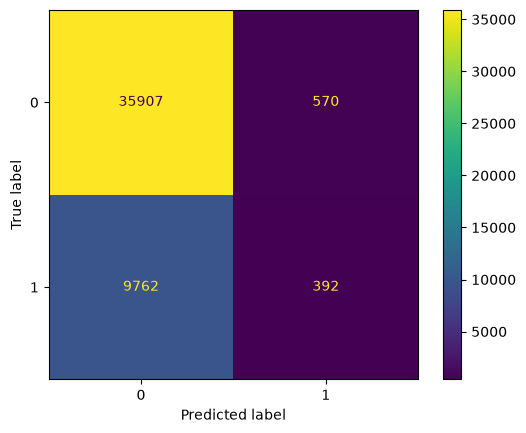



Accuracy:  0.7784306577169694
Precision:  0.4074844074844075
Recall:  0.03860547567461099
F1:  0.07052896725440806
AUC:  0.6271674728251733


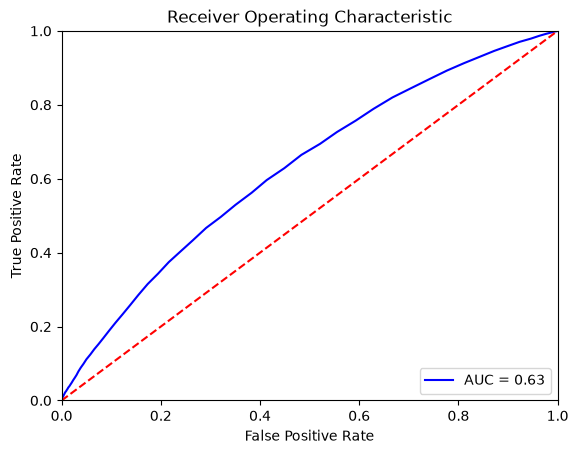

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

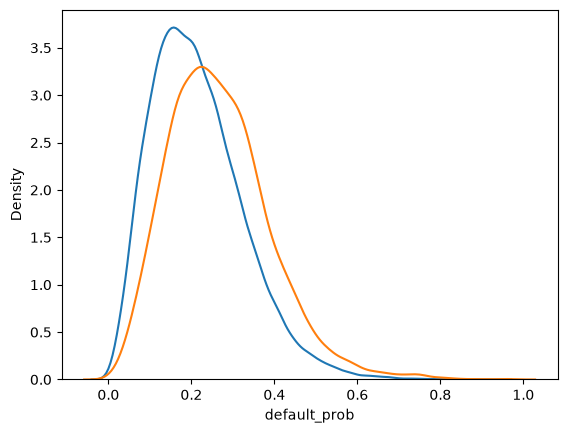

true_class  predicted_class
0           0                  0.984374
            1                  0.015626
1           0                  0.961395
            1                  0.038605
Name: proportion, dtype: float64


In [172]:
rfc_model = RandomForestClassifier()
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

In [173]:
#interpretation of results
#Accuracy: 78% simililar to the simple logistic regression model
#Precision: 39% better than simple logistic regression which had 33%
            #More of the instances classified as defaults were actually defaults
            #but most of the instances we classified as defaults were also not defaults
#Recall: Recall increased from 0.03% to 4.5%
         #Random forest picked a lot more of the actual positive cases but still missed most of them

#F1: The F1 score moved from 0.0006 to 0.08
     #There is better balance between precision and recall for random forest

In [174]:
#Overfitting

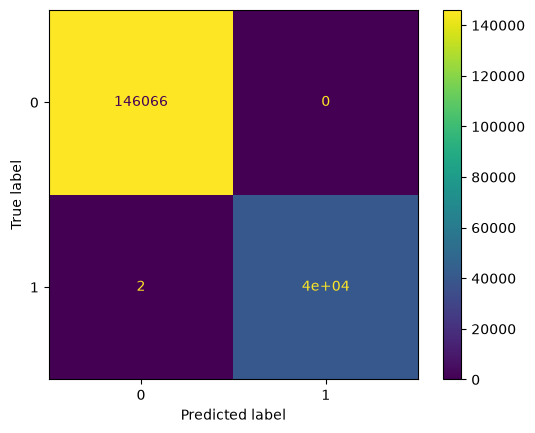



Accuracy:  0.9999892774617607
Precision:  1.0
Recall:  0.9999505647971921
F1:  0.9999752817876211
AUC:  1.0


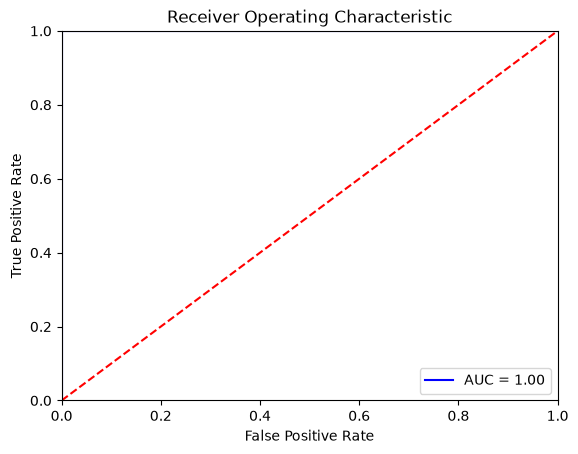

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

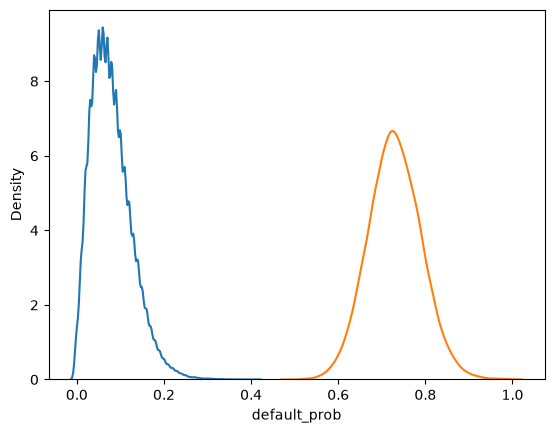

true_class  predicted_class
0           0                  1.000000
1           1                  0.999951
            0                  0.000049
Name: proportion, dtype: float64


In [175]:
#eval on training data
eval_model(rfc_model, x_train, y_train)

In [176]:
#The random forest is over fitting, it has perfect results on training data but poor results on test data

In [177]:
#Hyperparameters
#Classification performance of random forest can be heavily influenced by its hyperparameters
#hyperparameter tuning is the process of selecting optimal hyper parameters
#number of tree: how big is the forest? increasing number of trees increases performance
#maximum depth: the longest path between a tree root node and its deepest leaf node
                #limiting the depth of trees can be used to reduce overfitting.

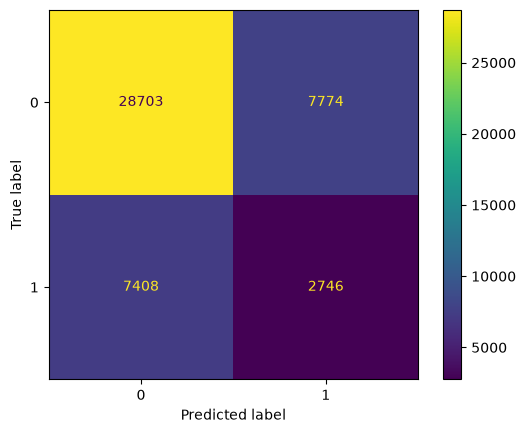



Accuracy:  0.674422594411443
Precision:  0.26102661596958177
Recall:  0.2704352964349025
F1:  0.2656476734062107
AUC:  0.5286573499473084


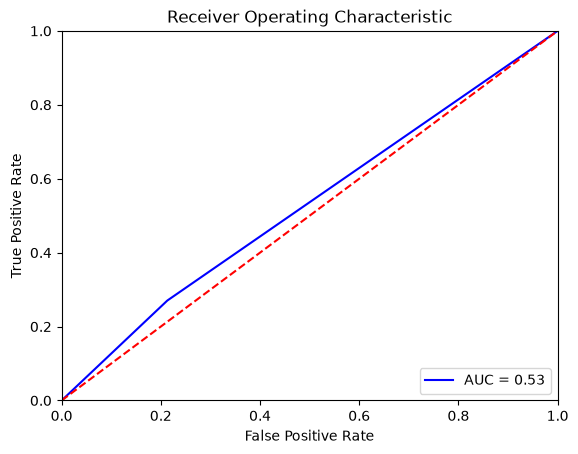

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

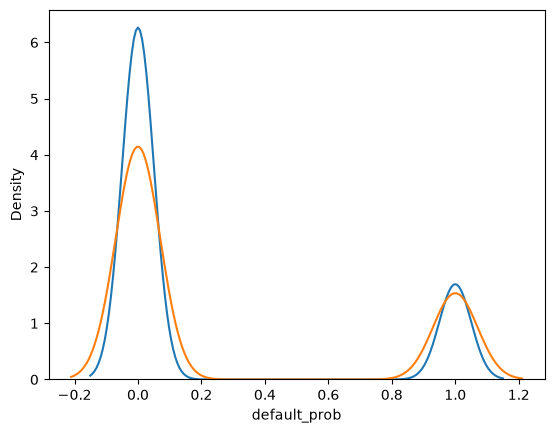

true_class  predicted_class
0           0                  0.786879
            1                  0.213121
1           0                  0.729565
            1                  0.270435
Name: proportion, dtype: float64


In [178]:
#Number of Trees
# 1 estimator
rfc_model = RandomForestClassifier(n_estimators=1)
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

In [179]:
#with a forest size of 1, the RF behaves as a standalone decision tree, uable to distinguish between 2 classes
#with AUC of 0.52 its only marginally better than a random classifier

In [180]:
#10 estimators
#with a forest size of 10 the separation ability f the model increases with an AUC of 0.58
#multiple peaks on distribution chart suggest this is not a very stable model

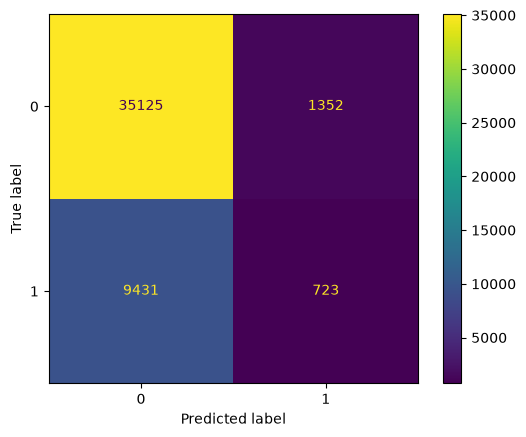



Accuracy:  0.7687589800776308
Precision:  0.34843373493975904
Recall:  0.07120346661414222
F1:  0.11824351950282116
AUC:  0.5833163281678939


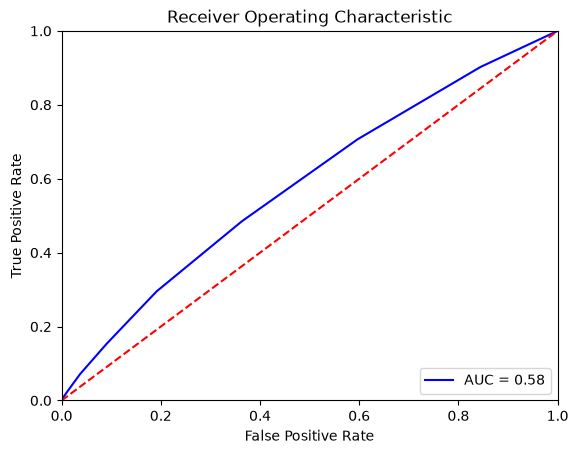

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

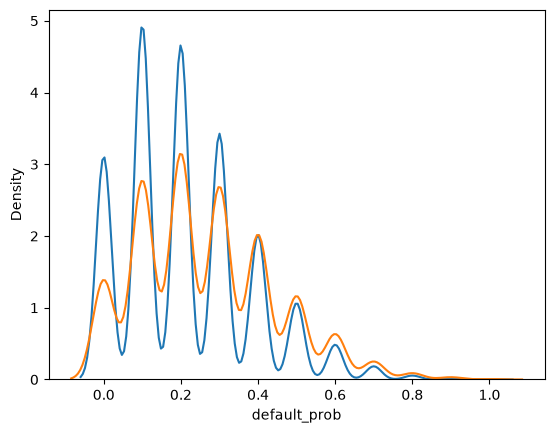

true_class  predicted_class
0           0                  0.962936
            1                  0.037064
1           0                  0.928797
            1                  0.071203
Name: proportion, dtype: float64


In [181]:
#10 estimators
rfc_model = RandomForestClassifier(n_estimators=10)
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

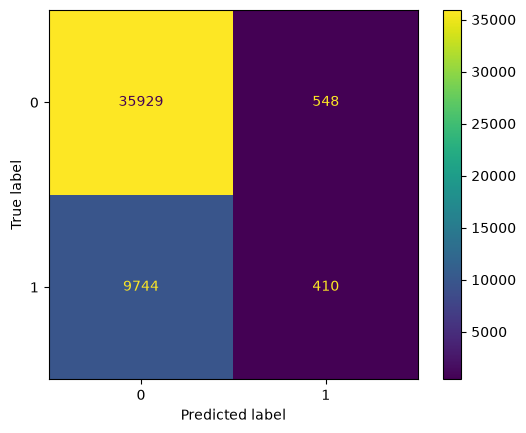



Accuracy:  0.7792884561772212
Precision:  0.4279749478079332
Recall:  0.04037817608824109
F1:  0.07379409647228222
AUC:  0.6269622161450187


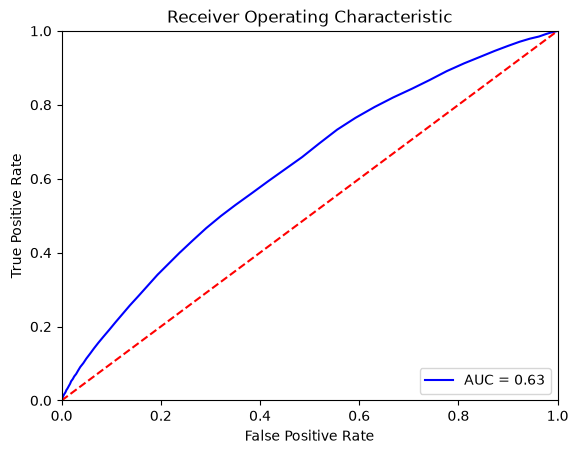

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

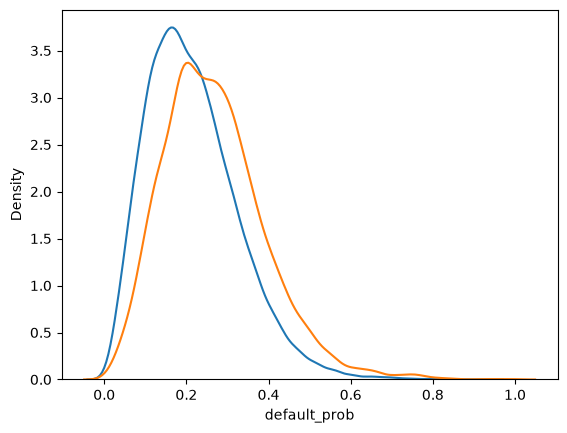

true_class  predicted_class
0           0                  0.984977
            1                  0.015023
1           0                  0.959622
            1                  0.040378
Name: proportion, dtype: float64


In [182]:
#100 estimators
# AUC improved from 0.58 to 0.62
# class distributions appeared more defined and settled
rfc_model = RandomForestClassifier(n_estimators=100)
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

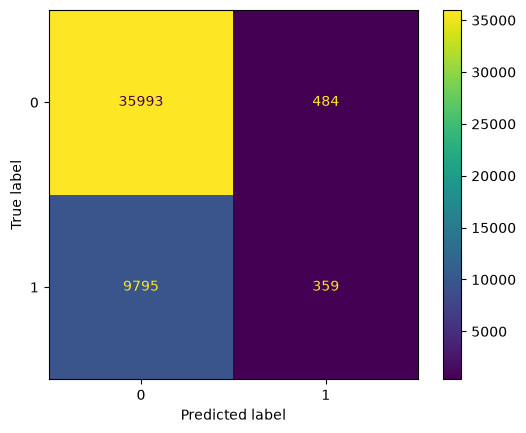



Accuracy:  0.7795672406768029
Precision:  0.4258600237247924
Recall:  0.03535552491628915
F1:  0.06529053378194052
AUC:  0.6322756506512163


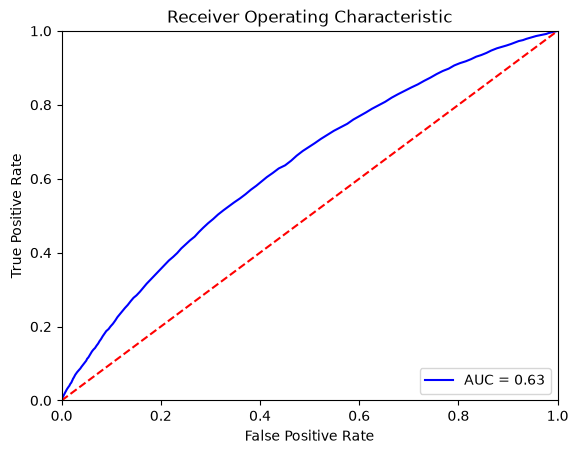

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

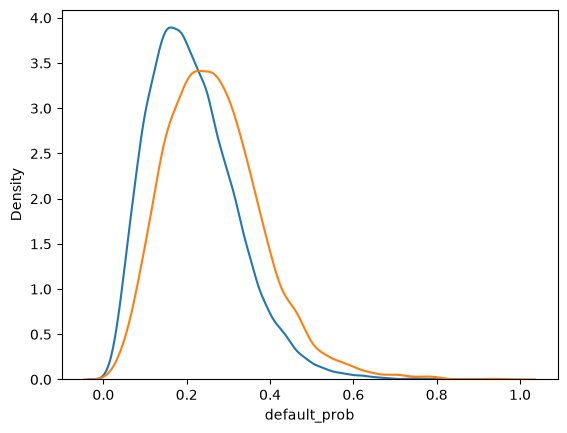

true_class  predicted_class
0           0                  0.986731
            1                  0.013269
1           0                  0.964644
            1                  0.035356
Name: proportion, dtype: float64


In [183]:
#300 estimators
#very similar to 100. increasing the size of the forest helps classification performance up to a point
#also increases computational cost of training the model
rfc_model = RandomForestClassifier(n_estimators=300)
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

In [184]:
#Maximum Depth
#One way of tackling overfitting is bt limiting maximum depth of the trees
#This preventsthe classifiers from growing too large picking up noise in the training data
#the default value of max_depth is none 

/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


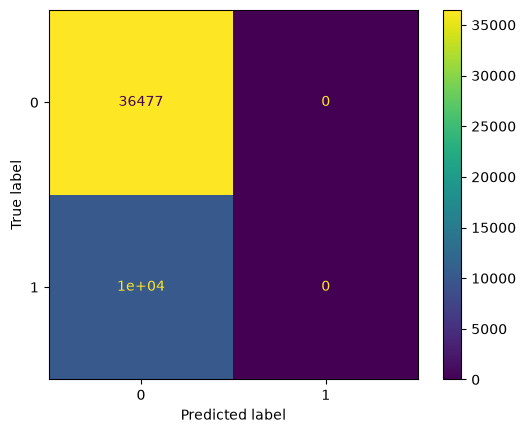



Accuracy:  0.7822478608650898
Precision:  0.0
Recall:  0.0
F1:  0.0
AUC:  0.632553405736541


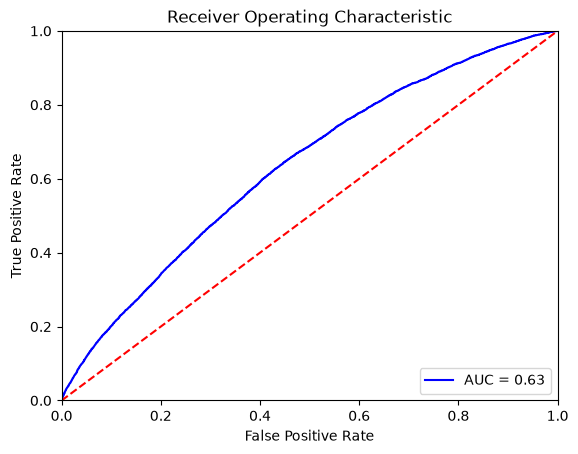

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

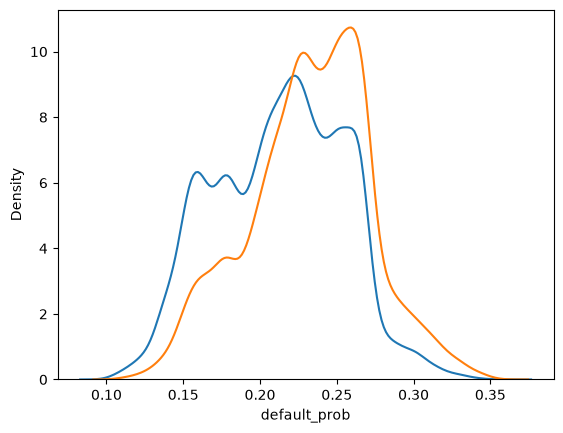

true_class  predicted_class
0           0                  1.0
1           0                  1.0
Name: proportion, dtype: float64


In [185]:
#max depth 5
##AUC is increased but model is failing to identify loan defaults
rfc_model = RandomForestClassifier(n_estimators=100, max_depth=5)
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


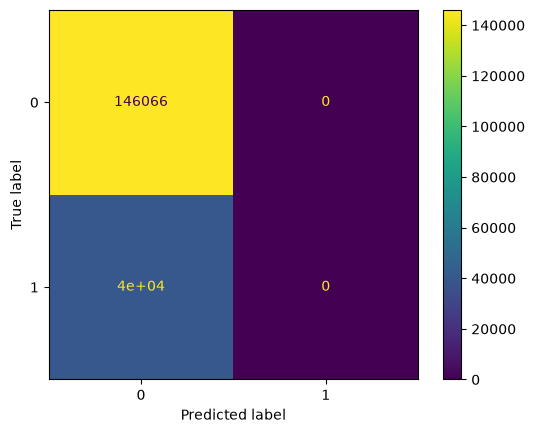



Accuracy:  0.783099135227291
Precision:  0.0
Recall:  0.0
F1:  0.0
AUC:  0.6416773690166884


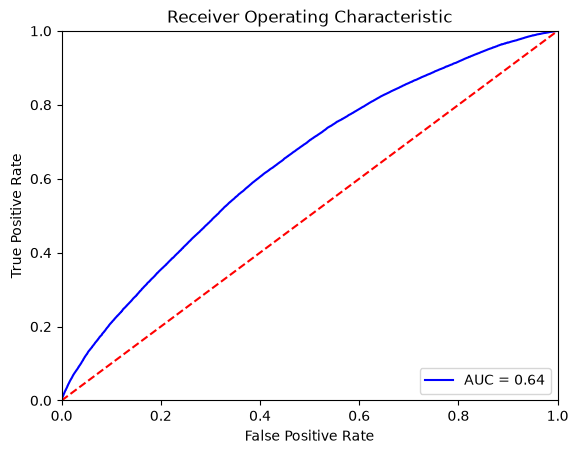

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

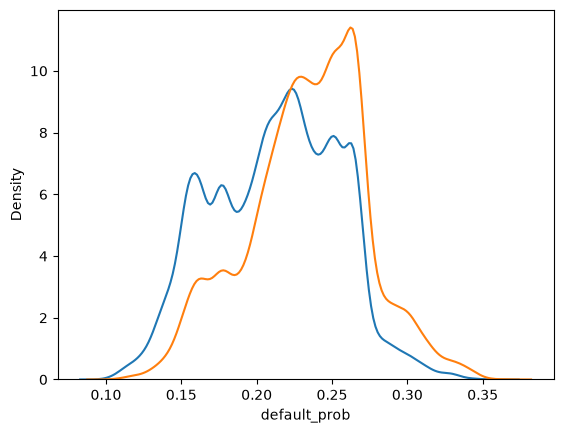

true_class  predicted_class
0           0                  1.0
1           0                  1.0
Name: proportion, dtype: float64


In [186]:
#how it performs on training data
#check for overfitting
#model isn't identifying any loan defaults. model has little predictive power 
eval_model(rfc_model, x_train, y_train)

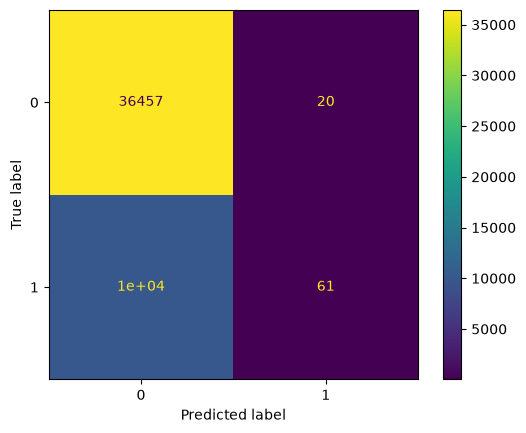



Accuracy:  0.7831271042868478
Precision:  0.7530864197530864
Recall:  0.006007484735079772
F1:  0.011919882755251588
AUC:  0.6493985455090653


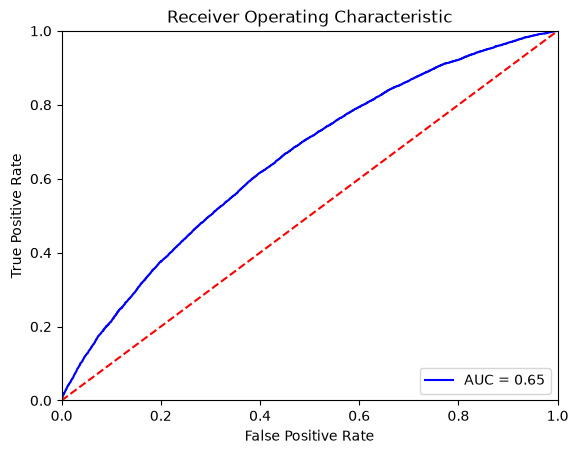

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

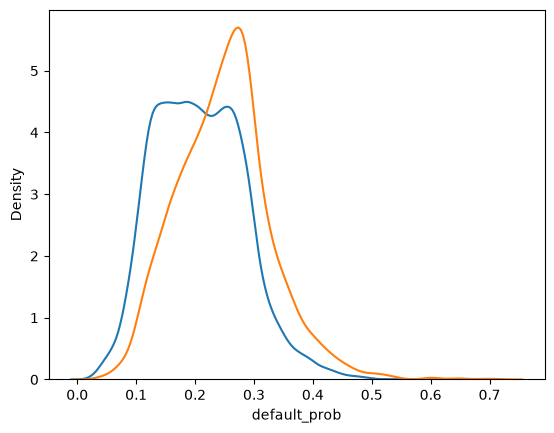

true_class  predicted_class
0           0                  0.999452
            1                  0.000548
1           0                  0.993993
            1                  0.006007
Name: proportion, dtype: float64


In [187]:
#max depth 15
# increased AUC to 0.65. model has ability to separate classes.
#good precision score of 67%. Identifying very few loan defaults due to poor recall
rfc_model = RandomForestClassifier(n_estimators=100, max_depth=15)
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

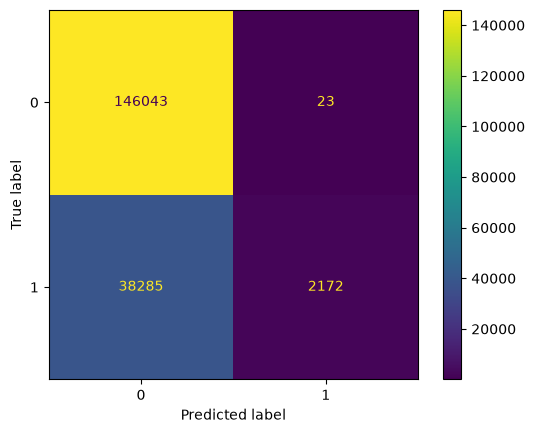



Accuracy:  0.7946205025653673
Precision:  0.9895216400911162
Recall:  0.053686630249400596
F1:  0.10184751008159054
AUC:  0.8359820205819672


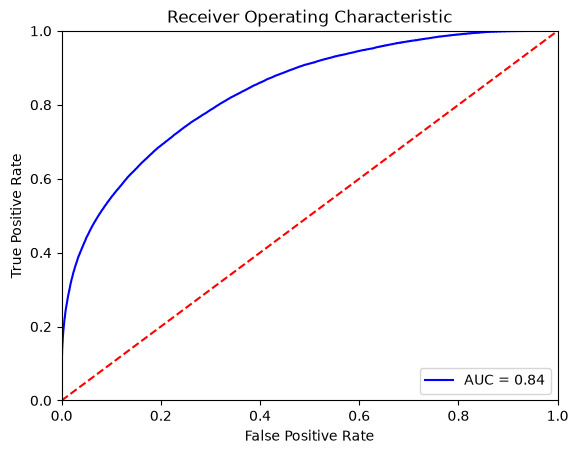

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

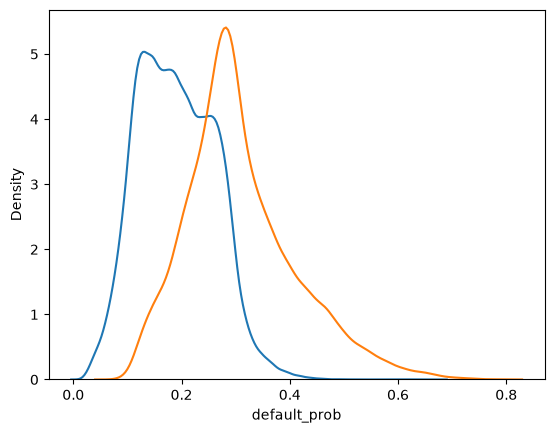

true_class  predicted_class
0           0                  0.999843
            1                  0.000157
1           0                  0.946313
            1                  0.053687
Name: proportion, dtype: float64


In [188]:
#check for overfitting
eval_model(rfc_model, x_train, y_train)

In [189]:
#Class balancing
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

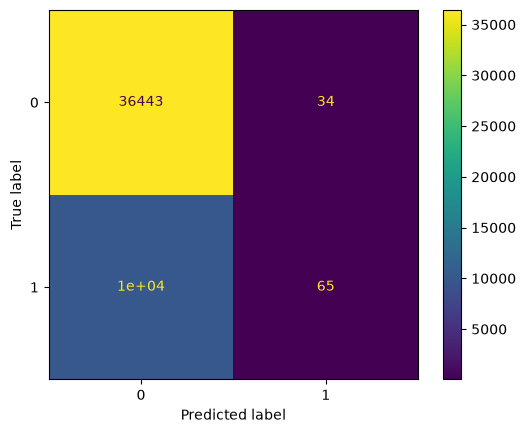



Accuracy:  0.7829126546717848
Precision:  0.6565656565656566
Recall:  0.006401418160330904
F1:  0.012679215839266556
AUC:  0.6491398771931419


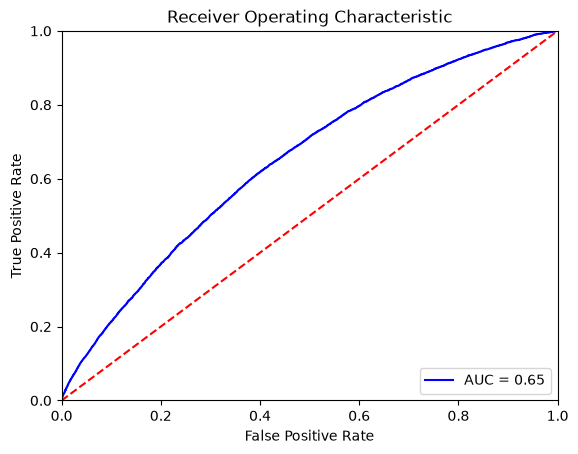

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

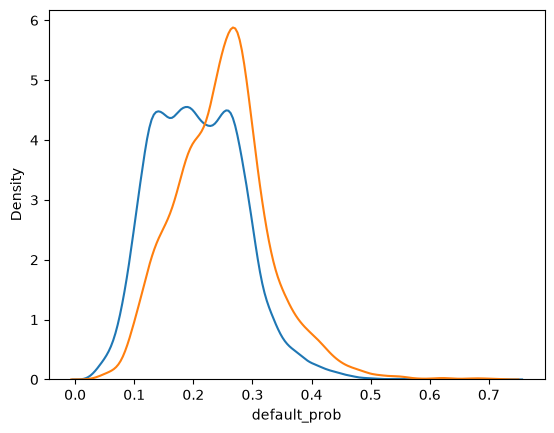

true_class  predicted_class
0           0                  0.999068
            1                  0.000932
1           0                  0.993599
            1                  0.006401
Name: proportion, dtype: float64


In [190]:
#class balancing using weight balancing techniques
x_train, x_test, y_train, y_test = encode_and_split(df2_loan)
rfc_model = RandomForestClassifier(n_estimators = 100, max_depth=15)

rfc_model.fit(x_train, y_train)
eval_model(rfc_model, x_test, y_test)

In [191]:
#random forest classifier has a weight parameter that can be used to address the problem of class imbalance
#by setting class weight to balanced , Sklearn automatically adjusts the weights to each class
#so that they have equal influence during model training

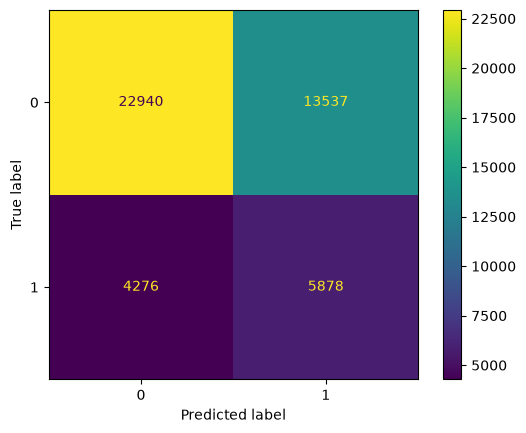



Accuracy:  0.6180009006883833
Precision:  0.30275560133917073
Recall:  0.5788851684065393
F1:  0.3975785450979066
AUC:  0.6457296564291333


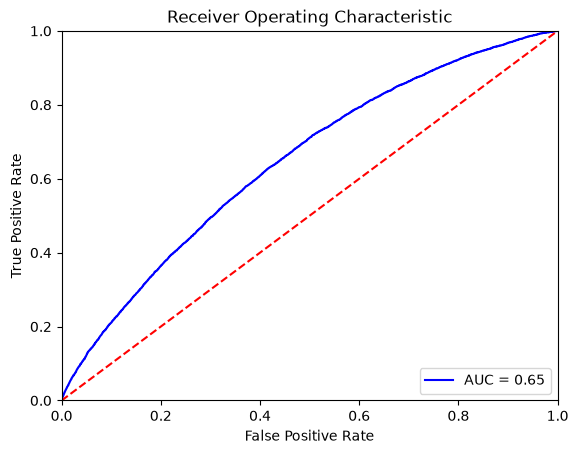

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

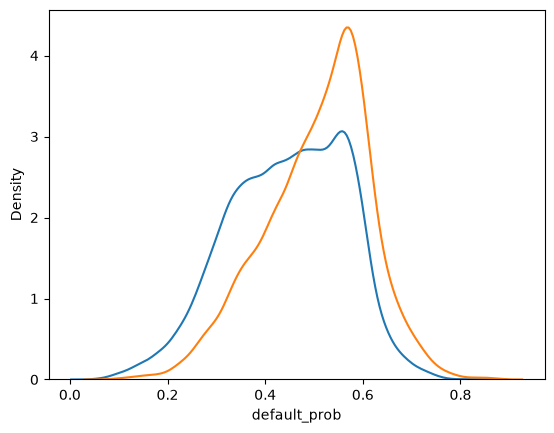

true_class  predicted_class
0           0                  0.628889
            1                  0.371111
1           1                  0.578885
            0                  0.421115
Name: proportion, dtype: float64


In [192]:
#balance rfc
rfc_model = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced')
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

In [193]:
#passing balanced to class weight parameter adjusts the class weights so that both classes carry equal influence
# we can pass a dictionary to class weights to manually set class weightings
#default (no class weightings) is equivalent to class_weight = {0:0.5, 1:0.5}
#balanced is equivalent to class weight {0:0.217, 1:0.783}
#balanced classes is incorrectly predicting too many defaults

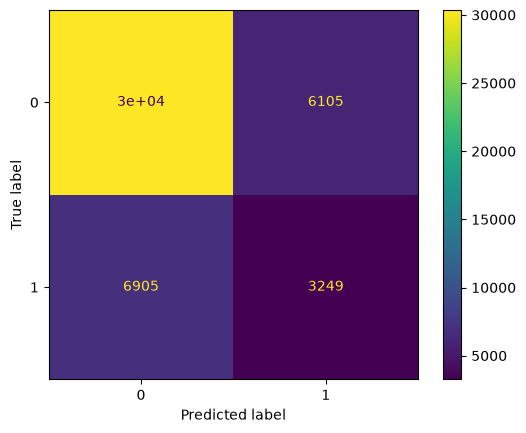



Accuracy:  0.7210010508031138
Precision:  0.34733803720333545
Recall:  0.3199724246602324
F1:  0.3330941152347755
AUC:  0.6469875472943255


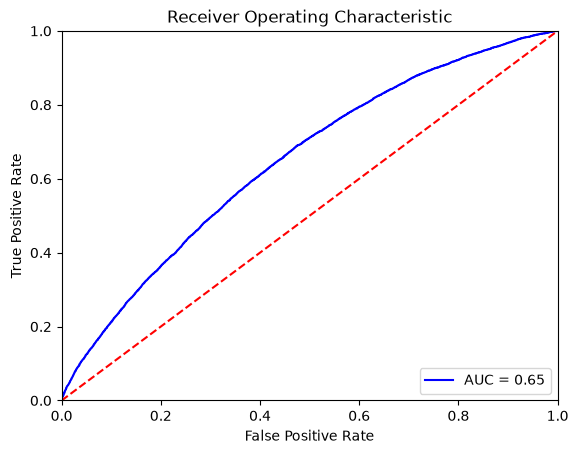

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

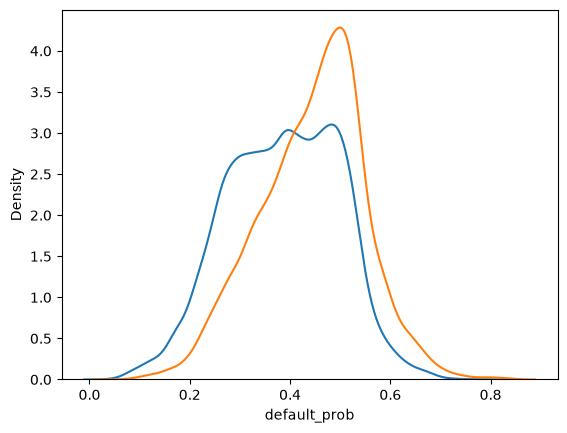

true_class  predicted_class
0           0                  0.832634
            1                  0.167366
1           0                  0.680028
            1                  0.319972
Name: proportion, dtype: float64


In [194]:
#manually weighted rfc
weights = {0:0.27, 1:0.73}
rfc_model = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight=weights)
rfc_model.fit(x_train, y_train)

eval_model(rfc_model, x_test, y_test)

In [195]:
#Resampling should be only done on training data
#test data should always reflect the natural class distribution
#upsampling is the process of resampling the minority classes to match the number of instances in majority
#we only want to resample the training data so let's join the x_train and y_train in to one DF
#we create a copy of x_train to avoid the need to recreate our train test split later

In [196]:
#copy x_train
train_df = x_train.copy()
train_df['LOAN_DEFAULT'] = y_train

In [197]:
#check target variable
print(train_df['LOAN_DEFAULT'].value_counts())
print(train_df['LOAN_DEFAULT'].value_counts(normalize=True))

LOAN_DEFAULT
0    146066
1     40457
Name: count, dtype: int64
LOAN_DEFAULT
0    0.783099
1    0.216901
Name: proportion, dtype: float64


In [198]:
#split by target classes
train_minority = train_df[train_df['LOAN_DEFAULT'] == 1]
train_majority = train_df[train_df['LOAN_DEFAULT'] == 0]

In [199]:
#perform upsampling
#no we have two DF train_majority and train_minority_up, which has the same number of rows
# all instances in majority should be class of 0 and instances in minority should be class of 1

In [200]:
#perform upsampling
train_minority_up = resample(train_minority, replace=True, n_samples=train_majority.shape[0], random_state=123)

In [201]:
#check class distribution
print(train_majority['LOAN_DEFAULT'].value_counts())
print(train_minority_up['LOAN_DEFAULT'].value_counts())

LOAN_DEFAULT
0    146066
Name: count, dtype: int64
LOAN_DEFAULT
1    146066
Name: count, dtype: int64


In [202]:
#create full training set
#join the two DF together using concat function
train_up_df = pd.concat([train_majority, train_minority_up])

In [203]:
#check target variable distribution
print(train_up_df['LOAN_DEFAULT'].value_counts())
print(train_up_df['LOAN_DEFAULT'].value_counts(normalize=True))

LOAN_DEFAULT
0    146066
1    146066
Name: count, dtype: int64
LOAN_DEFAULT
0    0.5
1    0.5
Name: proportion, dtype: float64


In [204]:
#split features from labels
x_train_up = train_up_df.drop(['LOAN_DEFAULT'], axis=1)
y_train_up = train_up_df['LOAN_DEFAULT']

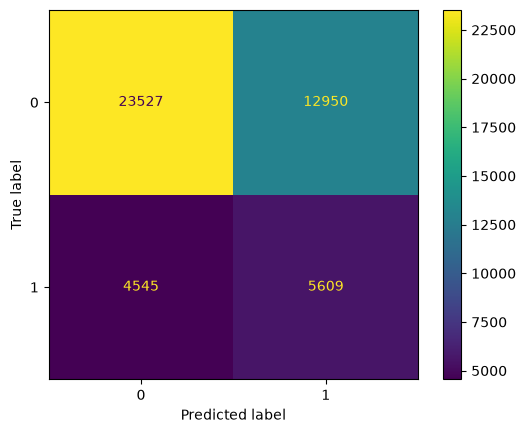



Accuracy:  0.6248203984473848
Precision:  0.30222533541677893
Recall:  0.5523931455584006
F1:  0.3906941106815728
AUC:  0.6422264708542048


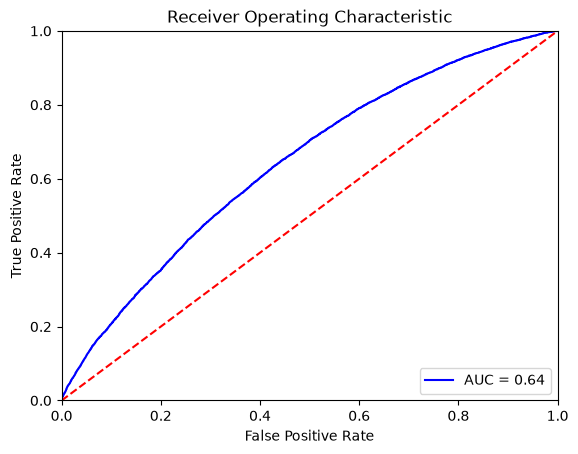

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

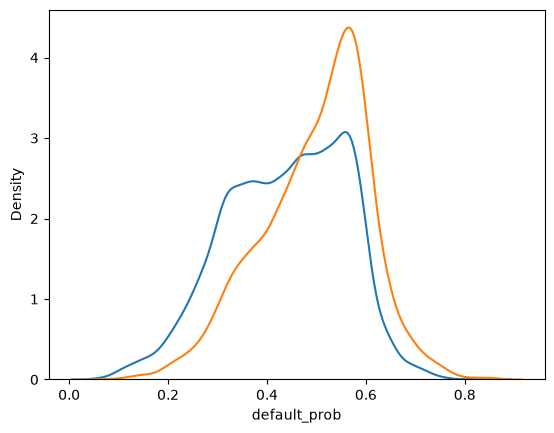

true_class  predicted_class
0           0                  0.644982
            1                  0.355018
1           1                  0.552393
            0                  0.447607
Name: proportion, dtype: float64


In [205]:
#train and eval
rfc_model = RandomForestClassifier(n_estimators=100, max_depth=15)
rfc_model.fit(x_train_up, y_train_up)

eval_model(rfc_model, x_test, y_test)

In [206]:
#downsampling
# produce balanced training data by downsampling the majority class to match the minority
# this is a function balance subsample to help easily perform up or downsampling
# balance sample function which can be used to produce the class balance for training set

In [207]:
def balance_sample(x_train, y_train, sample_mode='up'):
    train_df = x_train.copy()
    train_df['LOAN_DEFAULT'] = y_train

    train_minority = train_df[train_df['LOAN_DEFAULT'] == 1]
    train_majority = train_df[train_df['LOAN_DEFAULT'] == 0]

    train_sampled_df = pd.DataFrame()

    if sample_mode == 'down':
        train_majority_down = resample(train_majority, replace=False, n_samples=train_minority.shape[0], random_state=123)
        train_sampled_df = pd.concat([train_minority, train_majority_down])
    else:
        train_minority_up = resample(train_minority, replace=True, n_samples=train_majority.shape[0], random_state=123)
        train_sampled_df = pd.concat([train_majority, train_minority_up])

    x_train_samp = train_sampled_df.drop(['LOAN_DEFAULT'], axis=1)
    y_train_samp = train_sampled_df['LOAN_DEFAULT']

    return x_train_samp, y_train_samp
    

In [208]:
#using balance_sample function to create downsampled training data

In [209]:
x_train_down, y_train_down = balance_sample(x_train, y_train, sample_mode='down')

print(y_train_down.value_counts())
print(y_train_down.value_counts(normalize=True))

LOAN_DEFAULT
1    40457
0    40457
Name: count, dtype: int64
LOAN_DEFAULT
1    0.5
0    0.5
Name: proportion, dtype: float64


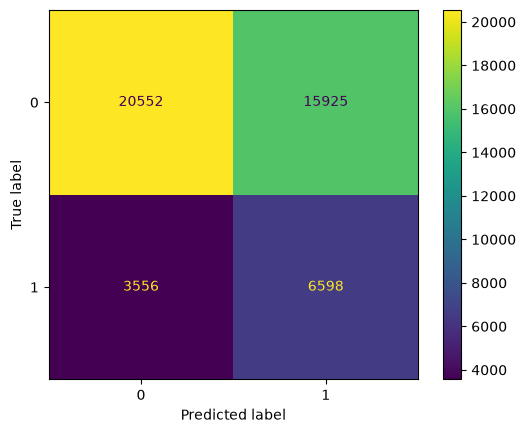



Accuracy:  0.5822307048958847
Precision:  0.29294498956622117
Recall:  0.6497931849517432
F1:  0.40383144107476204
AUC:  0.6471896991177277


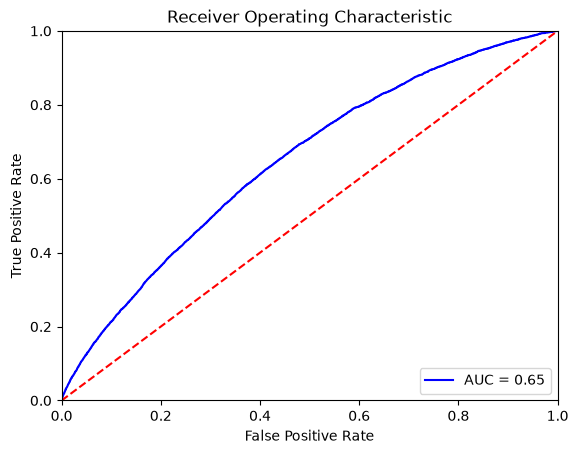

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

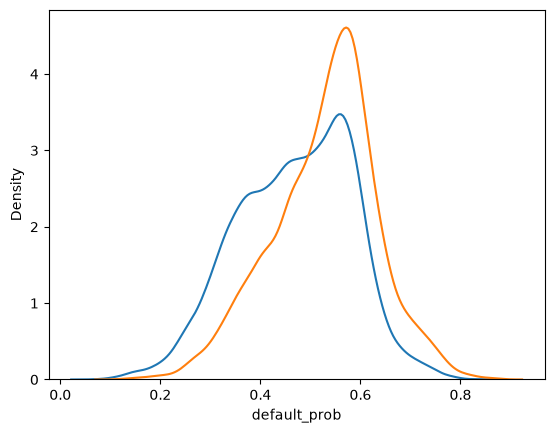

true_class  predicted_class
0           0                  0.563424
            1                  0.436576
1           1                  0.649793
            0                  0.350207
Name: proportion, dtype: float64


In [210]:
#train model
rfc_model = RandomForestClassifier(n_estimators = 100, max_depth = 15)

rfc_model.fit(x_train_down, y_train_down)
eval_model(rfc_model, x_test, y_test)

In [211]:
#smote upsamples the minoritty class
#rather than simply duplicating data, smote creates new synthetic instances
#using smote to create a synthetically upsampled training set

In [212]:
#initialize smote
smote = SMOTE()

In [213]:
#create sampled training data
x_train_synth, y_train_synth = smote.fit_resample(x_train, y_train)

In [214]:
#check class distribution
print(y_train_synth.value_counts())
print(y_train_synth.value_counts(normalize=True))

LOAN_DEFAULT
1    146066
0    146066
Name: count, dtype: int64
LOAN_DEFAULT
1    0.5
0    0.5
Name: proportion, dtype: float64


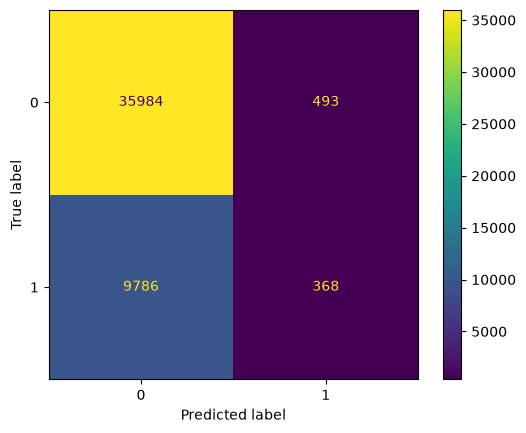



Accuracy:  0.7795672406768029
Precision:  0.4274099883855981
Recall:  0.03624187512310419
F1:  0.06681797548797094
AUC:  0.630732569243746


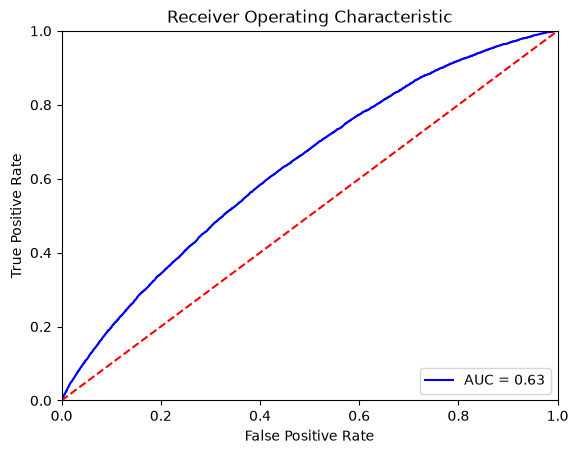

/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:44: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_df[results_df['true_class'] == 0]['default_prob'], label="No Default", hist=False)
/var/folders/5c/70n8vfws4m9glwpnh8rj2h540000gn/T/ipykernel_8559/1122684023.py:45: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist

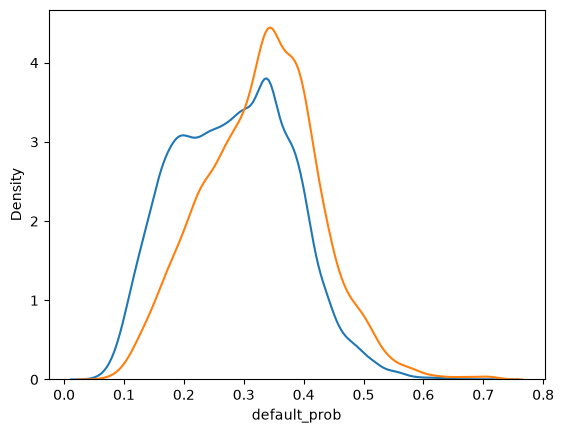

true_class  predicted_class
0           0                  0.986485
            1                  0.013515
1           0                  0.963758
            1                  0.036242
Name: proportion, dtype: float64


In [215]:
#train model
rfc_model = RandomForestClassifier(n_estimators = 100, max_depth = 15)

rfc_model.fit(x_train_synth, y_train_synth)
eval_model(rfc_model, x_test, y_test)

In [ ]:
#using smote has trained a model which labels a lot of our test data with default class
# the precision is poor around 30%
# Area Under Curve is down 0.62
#57% of defaulted loans labeled as non defaults